# Identity Hypothesis Exploration in WildChat

**Purpose:** Explore six hypotheses about identity and linguistic patterns in WildChat power users  
**Context:** The engagement prediction analysis (MTH-003) found that word count dominates prediction (AUC = 0.757 alone; 96% of permutation importance), while pronoun and style features contribute virtually nothing. However, descriptive analysis revealed an intriguing *inverted* pattern: power users show LOWER self-reference, LOWER "we" language, and LOWER direct address than moderate users.

---

## Hypotheses

| Hypothesis | Core Question |
|------------|---------------|
| H1: Efficiency Learning | Do users become more terse and less social over time? |
| H2: Tool vs Partner Types | Are there distinct user phenotypes with different linguistic signatures? |
| H3: "You" Collapse | Is declining direct address the key signal of instrumentalization? |
| H4: "We" Disappearance | Does joint-agency framing decline with heavy use? |
| H5: Qualitative Configurations | Can users be classified into identity configurations rather than measured on continuous dimensions? |
| H6: Content Over Style | Is identity revealed by *what* users discuss rather than *how* they write? |

**Goal**: Exploratory analysis with descriptive statistics and visualizations to determine which hypotheses merit formal testing.

---

## Contents

1. **Setup and Brand Configuration**
2. **Data Loading and User Statistics**
3. **Feature Loading/Computation**
4. **H1: Efficiency Learning** - Within-user temporal analysis
5. **H2: Tool vs Partner Types** - User clustering analysis
6. **H3: "You" Collapse** - Direct address analysis
7. **H4: "We" Disappearance** - Joint agency analysis
8. **H5: Qualitative Configurations** - Regex-based classification
9. **H6: Content Over Style** - Content marker analysis
10. **Summary and Hypothesis Evaluation**
11. **Output Checklist**


In [1]:
# ============================================================
# Setup & Brand Configuration
# ============================================================

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy import stats
import os
import re
import gc
import glob
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create output directory
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# =============================================================================
# PHRONOS BRAND COLORS (Light Mode)
# =============================================================================
BRAND = {
    'paper': '#F2F0E9',           # Primary background
    'ink': '#1A1A1A',             # Primary text/axes
    'gold': '#B08D55',            # Accent, highlights, signal
    'gold_dim': 'rgba(176, 141, 85, 0.12)',
    'faded': 'rgba(26, 26, 26, 0.5)',      # Secondary text
    'faded_light': 'rgba(26, 26, 26, 0.08)', # Borders, dividers
    'white': '#FFFFFF',           # Card backgrounds
    'alert': '#CC5544',           # Critical, errors (used for toxic)
    'success': '#44AA77',         # Positive states
}

# Convert rgba strings to matplotlib-compatible format
def rgba_to_tuple(rgba_str):
    """Convert 'rgba(r,g,b,a)' string to matplotlib tuple."""
    match = re.match(r'rgba\((\d+),\s*(\d+),\s*(\d+),\s*([\d.]+)\)', rgba_str)
    if match:
        r, g, b, a = match.groups()
        return (int(r)/255, int(g)/255, int(b)/255, float(a))
    return rgba_str

FADED = rgba_to_tuple('rgba(26, 26, 26, 0.5)')
FADED_LIGHT = rgba_to_tuple('rgba(26, 26, 26, 0.08)')

# =============================================================================
# MATPLOTLIB CONFIGURATION
# =============================================================================
plt.rcParams.update({
    # Figure
    'figure.facecolor': BRAND['paper'],
    'figure.edgecolor': BRAND['ink'],
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.facecolor': BRAND['paper'],
    'savefig.edgecolor': 'none',
    
    # Axes
    'axes.facecolor': BRAND['paper'],
    'axes.edgecolor': BRAND['ink'],
    'axes.labelcolor': BRAND['ink'],
    'axes.titlecolor': BRAND['ink'],
    'axes.linewidth': 1.0,
    'axes.grid': True,
    'axes.axisbelow': True,
    
    # Grid
    'grid.color': FADED_LIGHT,
    'grid.linewidth': 0.5,
    'grid.alpha': 1.0,
    
    # Ticks
    'xtick.color': BRAND['ink'],
    'ytick.color': BRAND['ink'],
    'xtick.labelcolor': BRAND['ink'],
    'ytick.labelcolor': BRAND['ink'],
    
    # Text
    'text.color': BRAND['ink'],
    
    # Font
    'font.family': 'monospace',
    'font.monospace': ['Fira Code', 'Consolas', 'Monaco', 'monospace'],
    'font.size': 10,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    
    # Legend
    'legend.facecolor': BRAND['white'],
    'legend.edgecolor': BRAND['ink'],
    'legend.framealpha': 1.0,
})

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def apply_phronos_style(ax, title=None, xlabel=None, ylabel=None):
    """Apply Phronos brand styling to an axes object."""
    ax.set_facecolor(BRAND['paper'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(BRAND['ink'])
    ax.spines['bottom'].set_color(BRAND['ink'])
    ax.tick_params(colors=BRAND['ink'], which='both')
    ax.grid(True, alpha=0.3, color=BRAND['ink'], linewidth=0.5)
    
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold', color=BRAND['ink'])
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11, color=BRAND['ink'])
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11, color=BRAND['ink'])

def save_figure(fig, name, tight=True):
    """Save figure with Phronos styling."""
    path = f'../outputs/figures/pub_{name}.png'
    if tight:
        fig.savefig(path, dpi=300, bbox_inches='tight', 
                    facecolor=BRAND['paper'], edgecolor='none')
    else:
        fig.savefig(path, dpi=300, facecolor=BRAND['paper'], edgecolor='none')
    print(f"Saved: {path}")
    return path

print("Phronos brand configuration loaded.")
print(f"  Paper: {BRAND['paper']}")
print(f"  Ink: {BRAND['ink']}")
print(f"  Gold: {BRAND['gold']}")
print(f"  Random state: {RANDOM_STATE}")


Phronos brand configuration loaded.
  Paper: #F2F0E9
  Ink: #1A1A1A
  Gold: #B08D55
  Random state: 42


In [2]:
# ============================================================
# Data Loading and User Statistics
# ============================================================

# Data paths
PROTEST_USERS = '../outputs/data/protest_with_users/*.parquet'
RAW_DATA = '../data/wildchat-raw/data/*.parquet'

# Load preprocessed data with user IDs
print("Loading data...")
df = pl.scan_parquet(PROTEST_USERS).collect()
print(f"Loaded {len(df):,} conversations")
print(f"Unique users: {df['user_id'].n_unique():,}")

# Add temporal columns
df = df.with_columns([
    pl.col('timestamp').dt.truncate('1mo').alias('month'),
    pl.col('timestamp').dt.strftime('%Y-%m').alias('year_month'),
])

# Create model_family if not exists
if 'model' in df.columns and 'model_family' not in df.columns:
    df = df.with_columns([
        pl.when(pl.col('model').str.contains('gpt-4o', literal=False))
          .then(pl.lit('GPT-4o'))
          .when(pl.col('model').str.contains('gpt-4', literal=False))
          .then(pl.lit('GPT-4'))
          .otherwise(pl.lit('GPT-3.5'))
          .alias('model_family')
    ])
elif 'model_family' not in df.columns:
    print("Warning: No model information found. Creating placeholder.")
    df = df.with_columns([pl.lit('Unknown').alias('model_family')])

# Compute user-level statistics
print("\nComputing user statistics...")
user_stats = df.group_by('user_id').agg([
    pl.len().alias('n_conversations'),
    pl.col('timestamp').min().alias('first_conv_date'),
    pl.col('timestamp').max().alias('last_conv_date'),
])

# Define engagement tiers
user_stats = user_stats.with_columns([
    pl.when(pl.col('n_conversations') >= 100).then(pl.lit('power'))
      .when(pl.col('n_conversations') >= 21).then(pl.lit('heavy'))
      .when(pl.col('n_conversations') >= 5).then(pl.lit('moderate'))
      .when(pl.col('n_conversations') >= 2).then(pl.lit('light'))
      .otherwise(pl.lit('one_shot'))
      .alias('engagement_tier')
])

# Summary by tier
print("\n" + "="*70)
print("USER ENGAGEMENT TIERS")
print("="*70)
tier_summary = user_stats.group_by('engagement_tier').agg([
    pl.len().alias('n_users'),
    pl.col('n_conversations').mean().alias('avg_conversations'),
    pl.col('n_conversations').sum().alias('total_conversations'),
])

tier_order = ['one_shot', 'light', 'moderate', 'heavy', 'power']
for tier in tier_order:
    tier_data = tier_summary.filter(pl.col('engagement_tier') == tier)
    if len(tier_data) > 0:
        row = tier_data.row(0, named=True)
        pct = 100 * row['n_users'] / len(user_stats)
        conv_pct = 100 * row['total_conversations'] / len(df)
        print(f"  {tier:<12}: {row['n_users']:>8,} users ({pct:>5.1f}%) | "
              f"{row['total_conversations']:>10,} convs ({conv_pct:>5.1f}%) | "
              f"avg {row['avg_conversations']:.1f} conv/user")

# Identify power users for detailed analysis
power_user_ids = set(user_stats.filter(pl.col('engagement_tier') == 'power')['user_id'].to_list())
print(f"\nPower users (100+ conversations): {len(power_user_ids):,}")

# Join engagement tier to main dataframe
df = df.join(user_stats.select(['user_id', 'engagement_tier', 'n_conversations']), on='user_id', how='left')

print("\n" + "="*70)
print("Data loading complete.")
print("="*70)


Loading data...
Loaded 4,743,336 conversations
Unique users: 2,462,800

Computing user statistics...

USER ENGAGEMENT TIERS
  one_shot    : 2,246,768 users ( 91.2%) |  2,246,768 convs ( 47.4%) | avg 1.0 conv/user
  light       :  151,055 users (  6.1%) |    378,545 convs (  8.0%) | avg 2.5 conv/user
  moderate    :   52,940 users (  2.1%) |    459,520 convs (  9.7%) | avg 8.7 conv/user
  heavy       :   10,332 users (  0.4%) |    407,621 convs (  8.6%) | avg 39.5 conv/user
  power       :    1,705 users (  0.1%) |  1,250,882 convs ( 26.4%) | avg 733.7 conv/user

Power users (100+ conversations): 1,705

Data loading complete.


In [3]:
# ============================================================
# Feature Extraction Functions and Computation
# ============================================================

def extract_first_turn(conversation):
    """Extract first user message from conversation."""
    if conversation is None:
        return None
    try:
        if isinstance(conversation, str):
            import json
            conv_list = json.loads(conversation)
        else:
            conv_list = conversation
        
        for turn in conv_list:
            if isinstance(turn, dict) and turn.get('role') == 'user':
                return turn.get('content', '')
        return None
    except:
        return None

def extract_first_turn_features(conversation):
    """Extract linguistic features from first user message."""
    first_user_msg = extract_first_turn(conversation)
    
    if not first_user_msg:
        return {
            'word_count': 0,
            'char_count': 0,
            'first_person_singular_rate': 0.0,
            'first_person_plural_rate': 0.0,
            'second_person_rate': 0.0,
            'politeness_rate': 0.0,
            'has_question': 0,
            'is_imperative': 0,
            'avg_word_length': 0.0,
            'is_greeting': 0,
        }
    
    text = first_user_msg
    text_lower = text.lower()
    words = text.split()
    n_words = len(words)
    
    if n_words == 0:
        return {
            'word_count': 0,
            'char_count': len(text),
            'first_person_singular_rate': 0.0,
            'first_person_plural_rate': 0.0,
            'second_person_rate': 0.0,
            'politeness_rate': 0.0,
            'has_question': 0,
            'is_imperative': 0,
            'avg_word_length': 0.0,
            'is_greeting': 0,
        }
    
    # Pronoun counts (per 100 words for rate)
    first_person_singular = sum(1 for w in words if w.lower() in {'i', 'me', 'my', 'mine', 'myself'})
    first_person_plural = sum(1 for w in words if w.lower() in {'we', 'us', 'our', 'ours', 'ourselves'})
    second_person = sum(1 for w in words if w.lower() in {'you', 'your', 'yours', 'yourself', 'yourselves', 'u'})
    
    # Politeness markers
    politeness_words = {'please', 'thank', 'thanks', 'appreciate', 'kindly'}
    politeness_count = sum(1 for w in words if w.lower() in politeness_words)
    
    # Question detection
    has_question = '?' in text or text_lower.startswith(('what', 'how', 'why', 'when', 'where', 'who', 'can', 'could', 'would', 'is', 'are', 'do', 'does'))
    
    # Imperative detection
    imperative_starters = {'write', 'create', 'make', 'generate', 'list', 'explain', 'tell', 'show', 'find', 'help', 'give'}
    first_word = words[0].lower().rstrip(',:;') if words else ''
    is_imperative = first_word in imperative_starters
    
    # Greeting detection
    greeting_patterns = {'hi', 'hello', 'hey', 'good morning', 'good evening', 'greetings'}
    is_greeting = any(text_lower.startswith(g) for g in greeting_patterns)
    
    # Average word length
    avg_word_length = np.mean([len(w) for w in words]) if words else 0.0
    
    return {
        'word_count': n_words,
        'char_count': len(text),
        'first_person_singular_rate': 100 * first_person_singular / n_words,
        'first_person_plural_rate': 100 * first_person_plural / n_words,
        'second_person_rate': 100 * second_person / n_words,
        'politeness_rate': 100 * politeness_count / n_words,
        'has_question': int(has_question),
        'is_imperative': int(is_imperative),
        'avg_word_length': avg_word_length,
        'is_greeting': int(is_greeting),
    }

def classify_intent(text):
    """Classify first-turn intent using keyword patterns."""
    if text is None:
        return 'other'
    text_lower = str(text).lower()
    
    patterns = [
        ('greeting', [r'^hi\\b', r'^hello', r'^hey\\b']),
        ('roleplay', [r'act as', r'you are a', r'pretend', r'roleplay', r'imagine you']),
        ('emotional_support', [r'i feel', r"i'm feeling", r'anxious', r'depressed', r'lonely', r'stressed']),
        ('creative_writing', [r'write a story', r'write a poem', r'creative', r'fiction']),
        ('coding', [r'\\bcode\\b', r'\\bpython\\b', r'\\bjavascript\\b', r'function', r'\\bapi\\b', r'debug', r'error']),
        ('explanation', [r'^explain', r'^what is', r'^how does', r'^why does']),
        ('translation', [r'translate', r'in (spanish|french|german|chinese|japanese)']),
    ]
    
    for intent, pattern_list in patterns:
        for pattern in pattern_list:
            if re.search(pattern, text_lower):
                return intent
    return 'other'

print("Feature extraction functions defined.")
print("  - extract_first_turn(): Get first user message")
print("  - extract_first_turn_features(): Extract linguistic features")
print("  - classify_intent(): Classify message intent")


Feature extraction functions defined.
  - extract_first_turn(): Get first user message
  - extract_first_turn_features(): Extract linguistic features
  - classify_intent(): Classify message intent


In [6]:
# ============================================================
# Load Features for Power Users from Raw Data
# ============================================================
# We need first-turn features for power users. Load from raw data.

print("="*70)
print("LOADING FIRST-TURN FEATURES FOR POWER USERS")
print("="*70)

# Get conversation hashes for power users
power_convs_meta = df.filter(pl.col('user_id').is_in(power_user_ids))

# Get all power user conversation hashes (deduplication happens after extraction)
power_conv_hashes = set(power_convs_meta['conversation_hash'].to_list())
print(f"\nPower user conversations to process: {len(power_conv_hashes):,}")

# Process raw parquet files to extract features
parquet_files = sorted(glob.glob(RAW_DATA))
print(f"Processing {len(parquet_files)} parquet files...")

all_features = []
hashes_found = set()

for file_idx, parquet_file in enumerate(parquet_files):
    # Load file and filter to power user conversations
    file_data = pl.read_parquet(
        parquet_file,
        columns=['conversation_hash', 'conversation']
    )
    
    file_filtered = file_data.filter(
        pl.col('conversation_hash').is_in(list(power_conv_hashes))
    )
    
    if len(file_filtered) == 0:
        del file_data, file_filtered
        gc.collect()
        continue
    
    # Extract features from this file's conversations
    for row in file_filtered.iter_rows(named=True):
        features = extract_first_turn_features(row['conversation'])
        features['conversation_hash'] = row['conversation_hash']
        
        # Also extract first turn text for intent classification
        first_turn = extract_first_turn(row['conversation'])
        features['first_turn'] = first_turn[:500] if first_turn else None  # Truncate for memory
        features['intent'] = classify_intent(first_turn)
        
        all_features.append(features)
        hashes_found.add(row['conversation_hash'])
    
    # Progress
    if (file_idx + 1) % 20 == 0:
        print(f"  Processed {file_idx+1}/{len(parquet_files)} files, found {len(all_features):,} conversations...")
    
    # Clean up
    del file_data, file_filtered
    gc.collect()

print(f"\nExtracted features for {len(all_features):,} power user conversations")
print(f"  Coverage: {100 * len(hashes_found) / len(power_conv_hashes):.1f}%")

# Create features DataFrame and deduplicate (raw data has ~4 duplicate rows per hash)
print(f"\nCreating DataFrame from {len(all_features):,} features...")
power_features = pl.DataFrame(all_features).unique(subset=['conversation_hash'])
print(f"After deduplication: {len(power_features):,} unique conversations")

# CRITICAL: Deduplicate power_convs_meta before join to prevent row explosion
power_convs_meta_dedup = power_convs_meta.unique(subset=['conversation_hash'])
print(f"Metadata rows: {len(power_convs_meta):,} -> {len(power_convs_meta_dedup):,} (after dedup)")

# Join with metadata (user_id, timestamp, etc.)
power_features = power_features.join(
    power_convs_meta_dedup.select(['conversation_hash', 'user_id', 'timestamp', 'year_month']),
    on='conversation_hash',
    how='left'
)

# Add conversation number within each user
power_features = power_features.sort(['user_id', 'timestamp']).with_columns([
    pl.col('timestamp').rank('ordinal').over('user_id').alias('conv_number')
])

# Join n_conversations from user_stats
power_features = power_features.join(
    user_stats.select(['user_id', 'n_conversations']).rename({'n_conversations': 'user_n_conversations'}),
    on='user_id',
    how='left'
)

print(f"\nFinal power_features shape: {power_features.shape}")
print(f"Estimated memory: {power_features.estimated_size('mb'):.1f} MB")

print(f"\nPower features DataFrame: {len(power_features):,} rows")
print(f"Columns: {power_features.columns}")

# Clean up
del all_features, power_convs_meta
gc.collect()

print("\n" + "="*70)
print("Feature loading complete.")
print("="*70)


LOADING FIRST-TURN FEATURES FOR POWER USERS

Power user conversations to process: 960,465
Processing 127 parquet files...
  Processed 20/127 files, found 197,707 conversations...
  Processed 40/127 files, found 444,086 conversations...
  Processed 60/127 files, found 559,875 conversations...
  Processed 80/127 files, found 583,397 conversations...
  Processed 100/127 files, found 888,080 conversations...
  Processed 120/127 files, found 1,084,812 conversations...

Extracted features for 1,278,931 power user conversations
  Coverage: 100.0%

Creating DataFrame from 1,278,931 features...
After deduplication: 960,465 unique conversations
Metadata rows: 1,250,882 -> 960,465 (after dedup)

Final power_features shape: (960465, 18)
Estimated memory: 683.5 MB

Power features DataFrame: 960,465 rows
Columns: ['word_count', 'char_count', 'first_person_singular_rate', 'first_person_plural_rate', 'second_person_rate', 'politeness_rate', 'has_question', 'is_imperative', 'avg_word_length', 'is_greet

H1: EFFICIENCY LEARNING - Within-User Temporal Analysis

Early conversations (first 10): 14,249
Late conversations (last 10): 11,243

----------------------------------------------------------------------
EARLY vs LATE CONVERSATIONS (Power Users)
----------------------------------------------------------------------
Feature                        Early           Late            Change          p-value   
----------------------------------------------------------------------
word_count                     707.677         846.860         +19.7%          0.0047
first_person_singular_rate     0.744           0.713           -4.2%           0.2875
first_person_plural_rate       0.124           0.153           +24.1%          0.0009
second_person_rate             0.800           0.691           -13.7%          0.0001
is_greeting                    0.017           0.010           -43.6%          0.0000
is_imperative                  0.194           0.179           -7.7%           0.0024
has_q

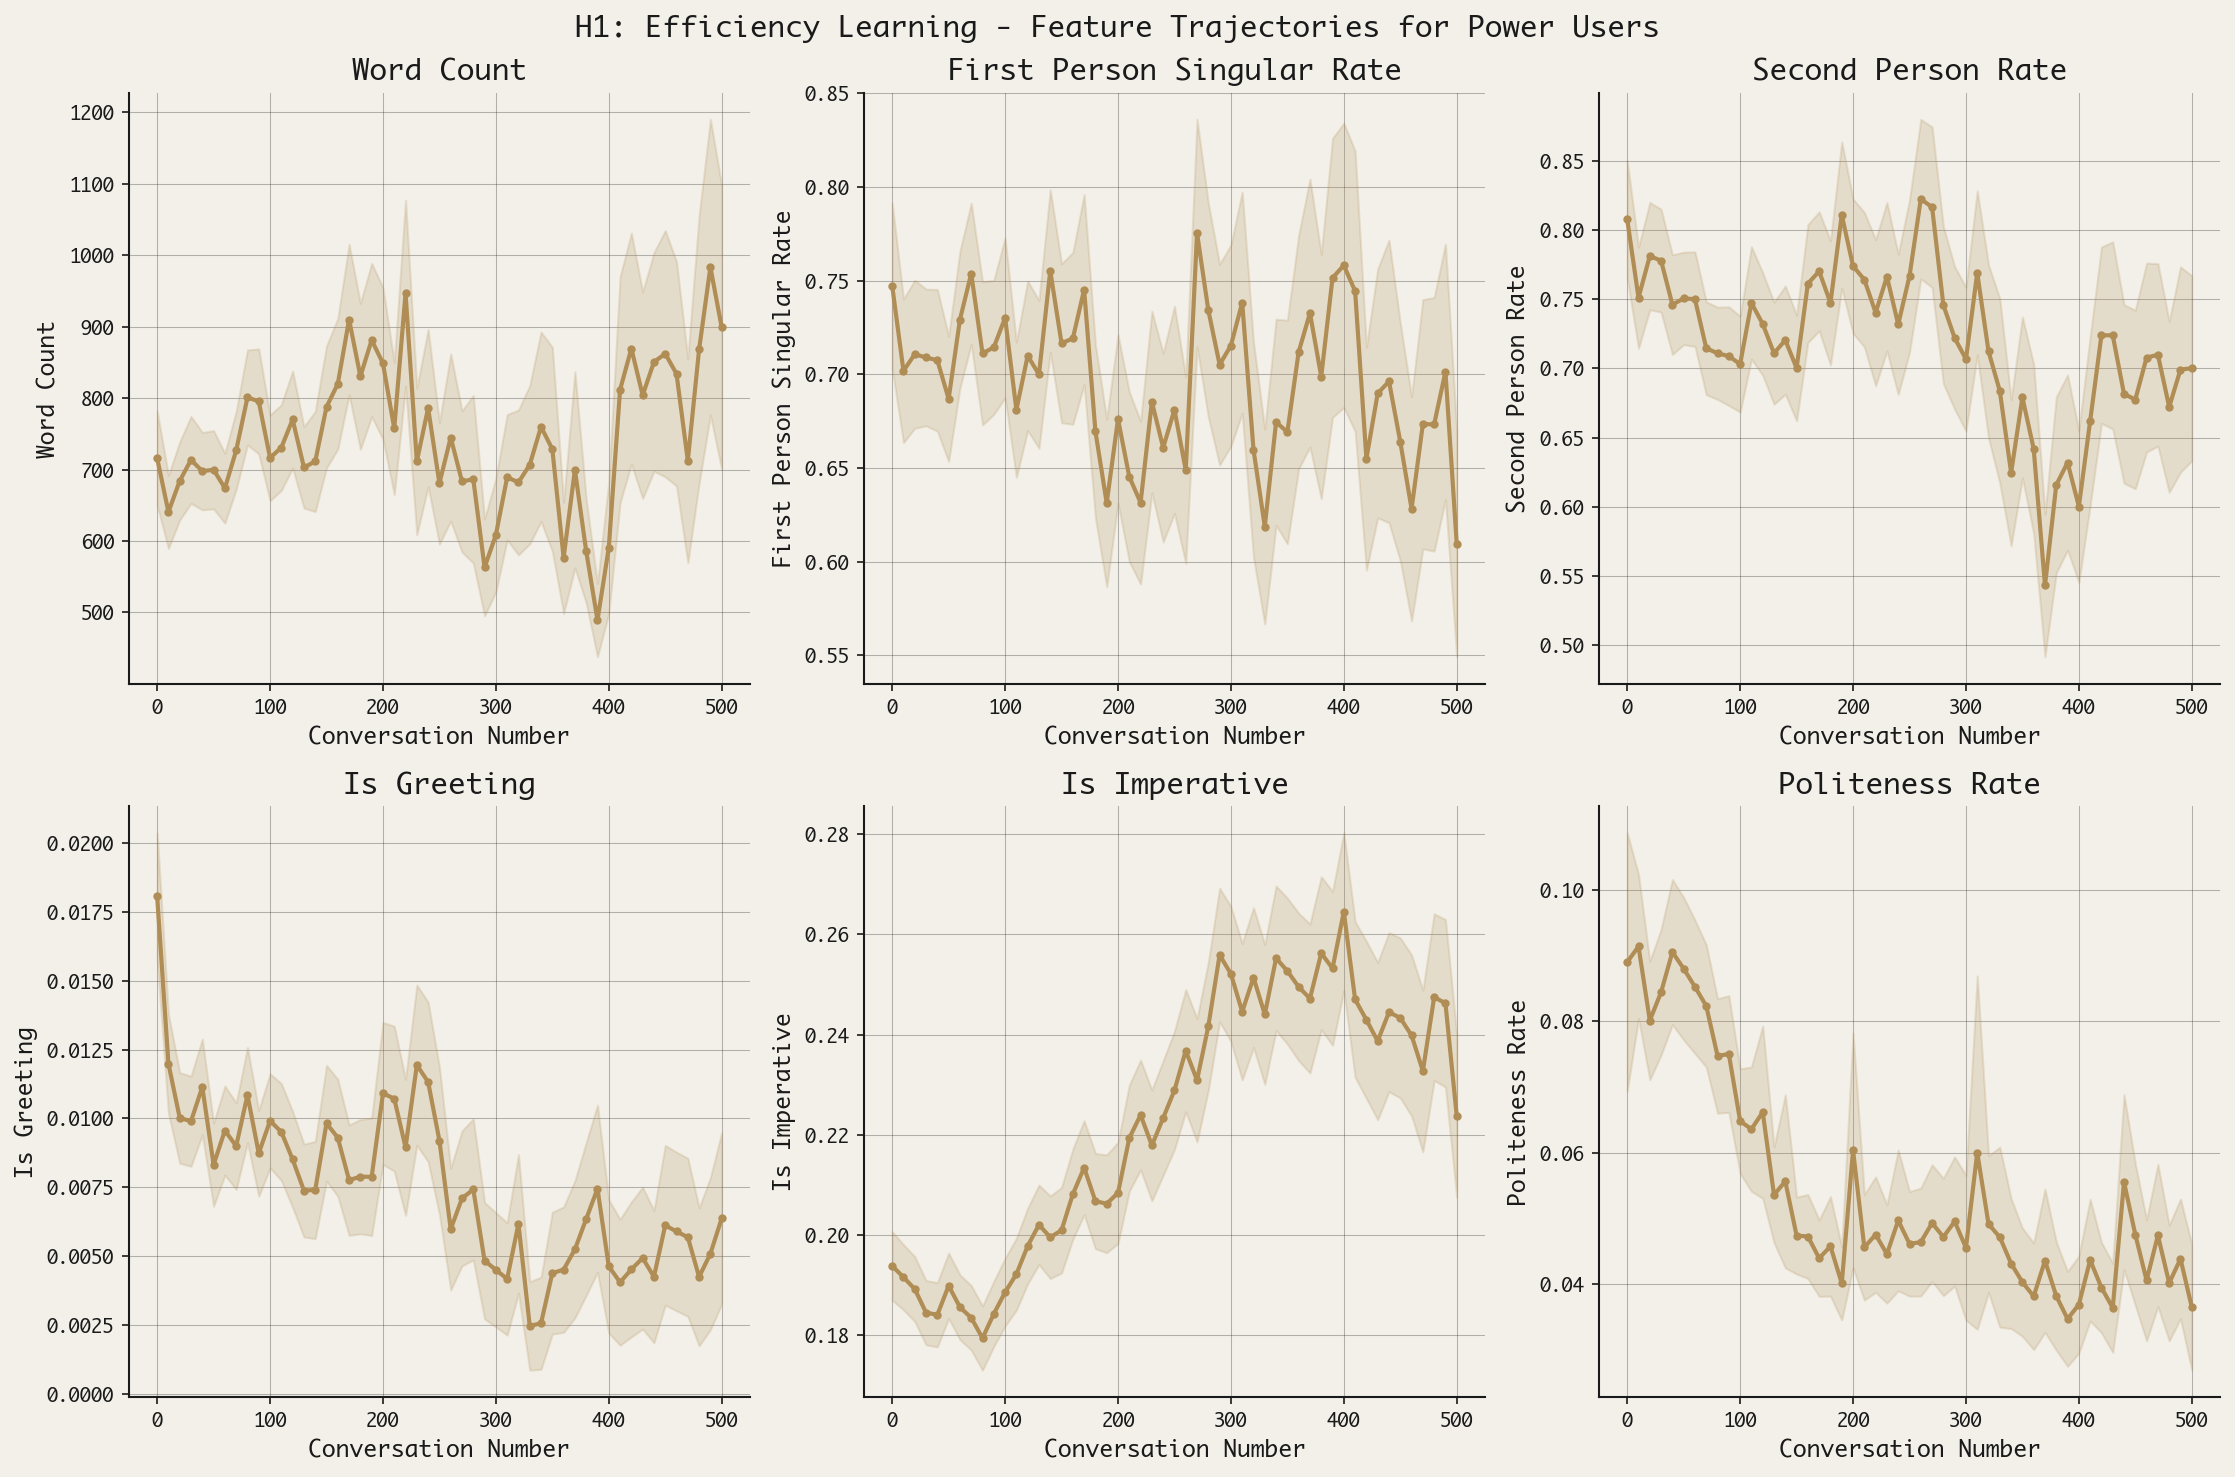

Saved: ../outputs/figures/pub_h1_paired_word_count_change.png


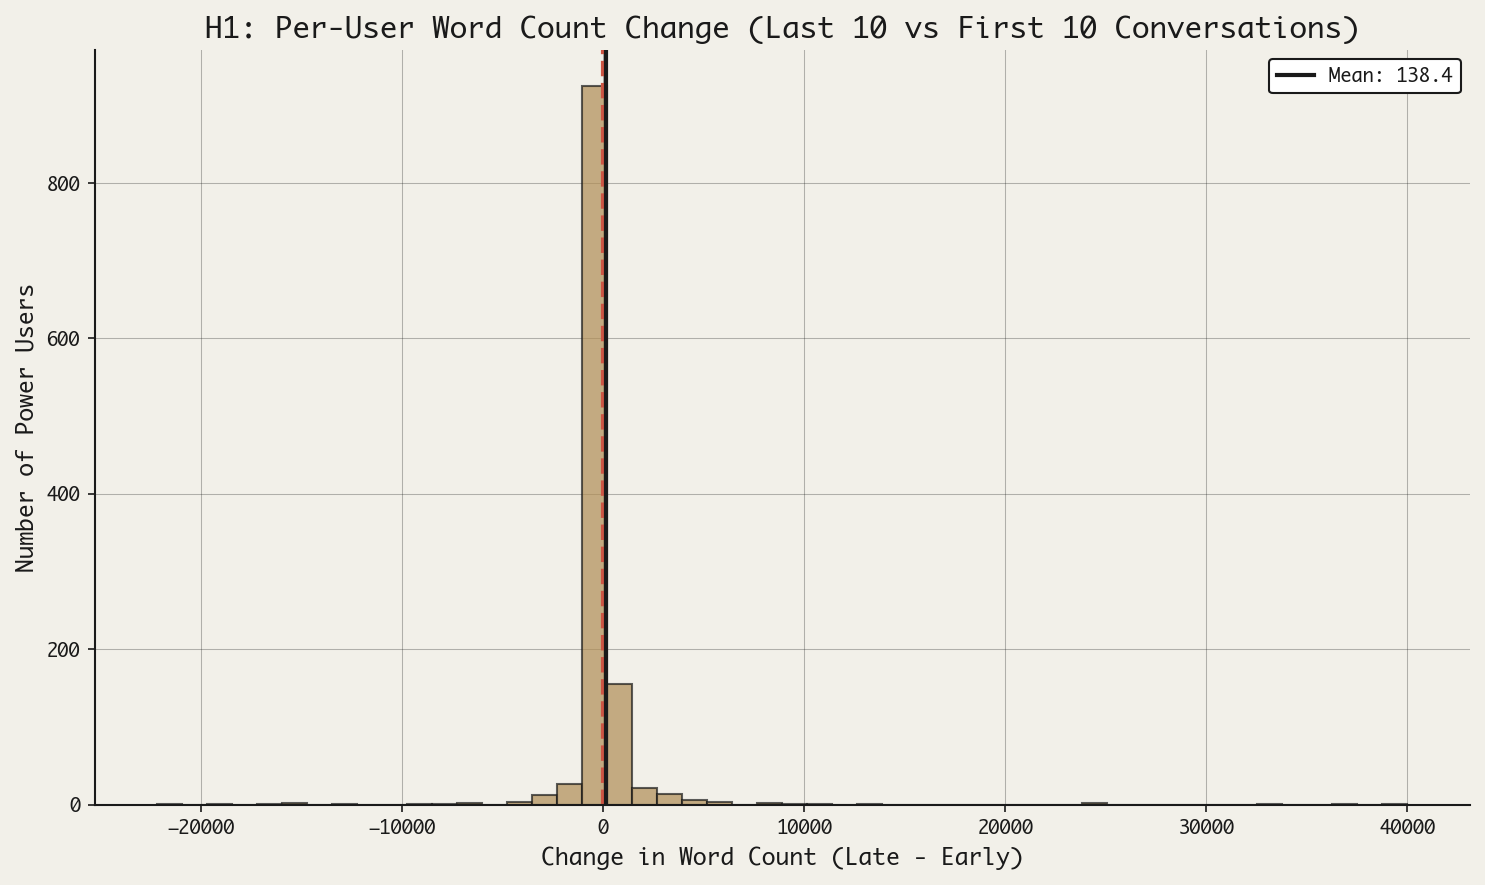


Paired t-test (word count): t=-1.77, p=0.0774

H1 SUMMARY
Features with significant change (p<0.05): 6/9
  - word_count: increases by 19.7%
  - first_person_plural_rate: increases by 24.1%
  - second_person_rate: decreases by 13.7%
  - is_greeting: decreases by 43.6%
  - is_imperative: decreases by 7.7%
  - has_question: increases by 5.2%


In [7]:
# ============================================================
# H1: EFFICIENCY LEARNING - Within-User Temporal Analysis
# ============================================================
# Hypothesis: Power users learn to prompt more efficiently over time.
# Early conversations are verbose and social; later conversations are terse and imperative.

print("="*70)
print("H1: EFFICIENCY LEARNING - Within-User Temporal Analysis")
print("="*70)

# Define early (first 10) and late (last 10) conversations
N_COMPARE = 10

early_convs = power_features.filter(pl.col('conv_number') <= N_COMPARE)
late_convs = power_features.filter(pl.col('conv_number') > pl.col('user_n_conversations') - N_COMPARE)

print(f"\nEarly conversations (first {N_COMPARE}): {len(early_convs):,}")
print(f"Late conversations (last {N_COMPARE}): {len(late_convs):,}")

# Features to compare
h1_features = [
    'word_count', 
    'first_person_singular_rate', 
    'first_person_plural_rate',
    'second_person_rate',
    'is_greeting',
    'is_imperative',
    'has_question',
    'politeness_rate',
    'avg_word_length'
]

print("\n" + "-"*70)
print("EARLY vs LATE CONVERSATIONS (Power Users)")
print("-"*70)
print(f"{'Feature':<30} {'Early':<15} {'Late':<15} {'Change':<15} {'p-value':<10}")
print("-"*70)

h1_results = []
for feature in h1_features:
    early_vals = early_convs[feature].drop_nulls().to_numpy()
    late_vals = late_convs[feature].drop_nulls().to_numpy()
    
    if len(early_vals) == 0 or len(late_vals) == 0:
        continue
    
    early_mean = np.mean(early_vals)
    late_mean = np.mean(late_vals)
    change = late_mean - early_mean
    pct_change = 100 * change / early_mean if early_mean != 0 else np.nan
    
    # Welch's t-test (unequal variances)
    t_stat, p_val = stats.ttest_ind(early_vals, late_vals, equal_var=False)
    
    change_str = f"{pct_change:>+.1f}%" if not np.isnan(pct_change) else "N/A"
    print(f"{feature:<30} {early_mean:<15.3f} {late_mean:<15.3f} {change_str:<15} {p_val:<.4f}")
    
    h1_results.append({
        'feature': feature,
        'early_mean': early_mean,
        'late_mean': late_mean,
        'pct_change': pct_change,
        'p_value': p_val
    })

h1_df = pl.DataFrame(h1_results)

# ============================================================
# Visualization H1a: Feature trajectories over conversation number
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('H1: Efficiency Learning - Feature Trajectories for Power Users', 
             fontsize=14, fontweight='bold', color=BRAND['ink'])

trajectory_features = ['word_count', 'first_person_singular_rate', 'second_person_rate',
                       'is_greeting', 'is_imperative', 'politeness_rate']

for ax, feature in zip(axes.flat, trajectory_features):
    # Compute mean by conversation number (binned for smoother curves)
    power_binned = power_features.with_columns([
        (pl.col('conv_number') / 10).floor().alias('conv_decile')
    ])
    
    trajectory = power_binned.group_by('conv_decile').agg([
        pl.col(feature).mean().alias('mean'),
        pl.col(feature).std().alias('std'),
        pl.len().alias('n')
    ]).sort('conv_decile').filter(pl.col('conv_decile') <= 50)  # First 500 conversations
    
    x = trajectory['conv_decile'].to_numpy() * 10
    y = trajectory['mean'].to_numpy()
    n_vals = trajectory['n'].to_numpy()
    std_vals = trajectory['std'].to_numpy()
    yerr = std_vals / np.sqrt(n_vals)  # Standard error
    
    ax.plot(x, y, color=BRAND['gold'], linewidth=2, marker='o', markersize=3)
    ax.fill_between(x, y - yerr*1.96, y + yerr*1.96, color=BRAND['gold'], alpha=0.2)
    ax.set_xlabel('Conversation Number')
    ax.set_ylabel(feature.replace('_', ' ').title())
    ax.set_title(feature.replace('_', ' ').title())
    apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'h1_efficiency_trajectories')
plt.show()

# ============================================================
# Visualization H1b: Paired comparison (early vs late)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Compute per-user change (late mean - early mean)
user_early = early_convs.group_by('user_id').agg([
    pl.col('word_count').mean().alias('early_word_count'),
    pl.col('second_person_rate').mean().alias('early_you_rate'),
    pl.col('is_greeting').mean().alias('early_greeting_rate'),
])

user_late = late_convs.group_by('user_id').agg([
    pl.col('word_count').mean().alias('late_word_count'),
    pl.col('second_person_rate').mean().alias('late_you_rate'),
    pl.col('is_greeting').mean().alias('late_greeting_rate'),
])

user_change = user_early.join(user_late, on='user_id').with_columns([
    (pl.col('late_word_count') - pl.col('early_word_count')).alias('word_count_change'),
    (pl.col('late_you_rate') - pl.col('early_you_rate')).alias('you_rate_change'),
    (pl.col('late_greeting_rate') - pl.col('early_greeting_rate')).alias('greeting_change'),
])

# Histogram of per-user word count changes
ax.hist(user_change['word_count_change'].to_numpy(), bins=50, color=BRAND['gold'], 
        edgecolor=BRAND['ink'], alpha=0.7)
ax.axvline(x=0, color=BRAND['alert'], linestyle='--', linewidth=2)
mean_change = user_change['word_count_change'].mean()
ax.axvline(x=mean_change, color=BRAND['ink'], 
           linestyle='-', linewidth=2, label=f"Mean: {mean_change:.1f}")
ax.set_xlabel('Change in Word Count (Late - Early)')
ax.set_ylabel('Number of Power Users')
ax.set_title('H1: Per-User Word Count Change (Last 10 vs First 10 Conversations)')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'h1_paired_word_count_change')
plt.show()

# Statistical test: paired t-test across users
t_stat, p_val = stats.ttest_rel(
    user_change['early_word_count'].to_numpy(),
    user_change['late_word_count'].to_numpy()
)
print(f"\nPaired t-test (word count): t={t_stat:.2f}, p={p_val:.4f}")

# Summary
print("\n" + "="*70)
print("H1 SUMMARY")
print("="*70)
significant_changes = h1_df.filter(pl.col('p_value') < 0.05)
print(f"Features with significant change (p<0.05): {len(significant_changes)}/{len(h1_df)}")
for row in significant_changes.iter_rows(named=True):
    direction = "decreases" if row['pct_change'] < 0 else "increases"
    print(f"  - {row['feature']}: {direction} by {abs(row['pct_change']):.1f}%")


H2: TOOL VS PARTNER TYPES - User Clustering Analysis
Power user profiles computed: 1,533

----------------------------------------------------------------------
CLUSTERING RESULTS
----------------------------------------------------------------------

--- K=2 Clustering ---
  Cluster 0: n=1139, top_intent=other, word_count=443, you_rate=0.297, greeting=0.50%
  Cluster 1: n=394, top_intent=other, word_count=1595, you_rate=1.981, greeting=3.88%

--- K=3 Clustering ---
  Cluster 0: n=1133, top_intent=other, word_count=442, you_rate=0.295, greeting=0.58%
  Cluster 1: n=389, top_intent=other, word_count=1622, you_rate=1.968, greeting=1.28%
  Cluster 2: n=11, top_intent=other, word_count=169, you_rate=1.757, greeting=86.38%

--- K=4 Clustering ---
  Cluster 0: n=19, top_intent=roleplay, word_count=20048, you_rate=0.375, greeting=1.47%
  Cluster 1: n=1164, top_intent=other, word_count=499, you_rate=0.306, greeting=0.61%
  Cluster 2: n=339, top_intent=other, word_count=502, you_rate=2.173, gre

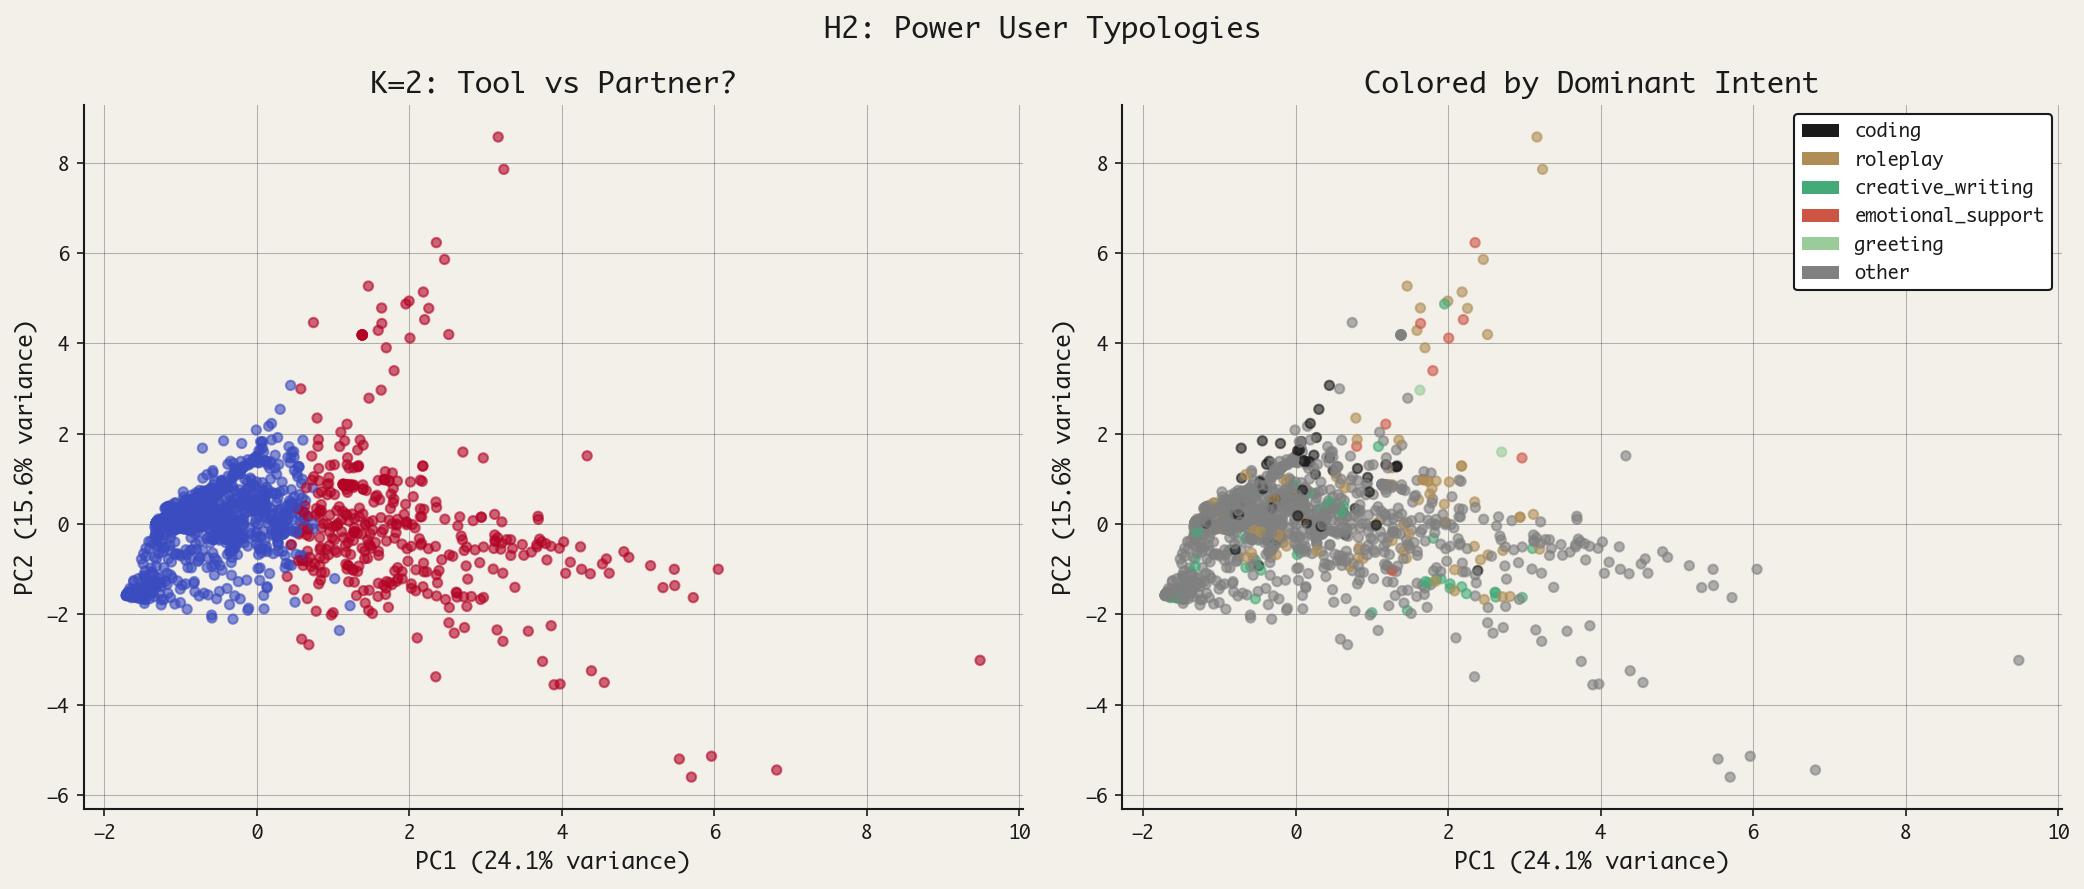


H2 SUMMARY: CLUSTER PROFILES (K=2)

Cluster 0 (n=1,139):
  mean_word_count: 443.333
  mean_i_rate: 0.278
  mean_we_rate: 0.049
  mean_you_rate: 0.297
  greeting_rate: 0.005
  imperative_rate: 0.184
  question_rate: 0.259
  mean_politeness: 0.040
  Top intents: other (87%), coding (4%), translation (4%), 

Cluster 1 (n=394):
  mean_word_count: 1595.307
  mean_i_rate: 1.777
  mean_we_rate: 0.365
  mean_you_rate: 1.981
  greeting_rate: 0.039
  imperative_rate: 0.132
  question_rate: 0.621
  mean_politeness: 0.168
  Top intents: other (74%), roleplay (15%), creative_writing (5%), 


In [8]:
# ============================================================
# H2: TOOL VS PARTNER TYPES - User Clustering Analysis
# ============================================================
# Hypothesis: There are distinct power user phenotypes—tool-oriented users 
# (coding, terse, low pronouns) and partner-oriented users (roleplay, social, higher pronouns).

print("="*70)
print("H2: TOOL VS PARTNER TYPES - User Clustering Analysis")
print("="*70)

# Compute user-level linguistic profiles
user_profiles = power_features.group_by('user_id').agg([
    pl.col('word_count').mean().alias('mean_word_count'),
    pl.col('first_person_singular_rate').mean().alias('mean_i_rate'),
    pl.col('first_person_plural_rate').mean().alias('mean_we_rate'),
    pl.col('second_person_rate').mean().alias('mean_you_rate'),
    pl.col('is_greeting').mean().alias('greeting_rate'),
    pl.col('is_imperative').mean().alias('imperative_rate'),
    pl.col('has_question').mean().alias('question_rate'),
    pl.col('politeness_rate').mean().alias('mean_politeness'),
    pl.col('intent').mode().first().alias('dominant_intent'),
    pl.len().alias('n_conversations'),
])

print(f"Power user profiles computed: {len(user_profiles):,}")

# Features for clustering
cluster_features = [
    'mean_word_count', 'mean_i_rate', 'mean_we_rate', 'mean_you_rate',
    'greeting_rate', 'imperative_rate', 'question_rate', 'mean_politeness'
]

# Prepare feature matrix
X_cluster = user_profiles.select(cluster_features).to_numpy()
X_cluster = np.nan_to_num(X_cluster, nan=0.0)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-means clustering
print("\n" + "-"*70)
print("CLUSTERING RESULTS")
print("-"*70)

cluster_results = {}
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # Add cluster labels to profiles
    user_profiles = user_profiles.with_columns([
        pl.Series(f'cluster_k{k}', labels)
    ])
    
    print(f"\n--- K={k} Clustering ---")
    for cluster_id in range(k):
        cluster_data = user_profiles.filter(pl.col(f'cluster_k{k}') == cluster_id)
        n_users = len(cluster_data)
        
        # Get dominant intent
        intent_counts = cluster_data['dominant_intent'].value_counts().sort('count', descending=True)
        top_intent = intent_counts['dominant_intent'][0] if len(intent_counts) > 0 else 'unknown'
        
        mean_wc = cluster_data['mean_word_count'].mean()
        mean_you = cluster_data['mean_you_rate'].mean()
        mean_greeting = cluster_data['greeting_rate'].mean()
        
        print(f"  Cluster {cluster_id}: n={n_users}, top_intent={top_intent}, "
              f"word_count={mean_wc:.0f}, you_rate={mean_you:.3f}, greeting={mean_greeting:.2%}")
    
    cluster_results[k] = labels

# ============================================================
# Visualization H2a: PCA projection with cluster coloring
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('H2: Power User Typologies', fontsize=14, fontweight='bold', color=BRAND['ink'])

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot k=2 clustering
ax = axes[0]
kmeans_2 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
labels_2 = kmeans_2.fit_predict(X_scaled)
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_2, cmap='coolwarm', alpha=0.6, s=20)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('K=2: Tool vs Partner?')
apply_phronos_style(ax)

# Plot by dominant intent
ax = axes[1]
intent_colors = {
    'coding': BRAND['ink'], 
    'roleplay': BRAND['gold'], 
    'creative_writing': BRAND['success'], 
    'emotional_support': BRAND['alert'],
    'explanation': '#6699CC',
    'greeting': '#99CC99',
    'other': 'gray'
}
intents = user_profiles['dominant_intent'].to_list()
colors = [intent_colors.get(i, 'gray') for i in intents]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, s=20)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Colored by Dominant Intent')

# Legend
legend_elements = [Patch(facecolor=c, label=i) for i, c in intent_colors.items() if i in set(intents)]
ax.legend(handles=legend_elements, loc='upper right', facecolor=BRAND['white'], edgecolor=BRAND['ink'])
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'h2_user_typologies_pca')
plt.show()

# ============================================================
# H2 Summary: Cluster profiles
# ============================================================

print("\n" + "="*70)
print("H2 SUMMARY: CLUSTER PROFILES (K=2)")
print("="*70)

for cluster_id in [0, 1]:
    cluster_data = user_profiles.filter(pl.col('cluster_k2') == cluster_id)
    print(f"\nCluster {cluster_id} (n={len(cluster_data):,}):")
    
    # Feature means
    for feat in cluster_features:
        mean_val = cluster_data[feat].mean()
        print(f"  {feat}: {mean_val:.3f}")
    
    # Intent distribution
    intent_dist = cluster_data['dominant_intent'].value_counts().sort('count', descending=True).head(3)
    print(f"  Top intents: ", end="")
    for row in intent_dist.iter_rows(named=True):
        pct = 100 * row['count'] / len(cluster_data)
        print(f"{row['dominant_intent']} ({pct:.0f}%), ", end="")
    print()


H3: THE 'YOU' COLLAPSE - Direct Address Analysis

Loading sample of features across all engagement tiers...
  one_shot: 30,000 conversations
  light: 30,000 conversations
  moderate: 30,000 conversations
  heavy: 30,000 conversations
  power: 30,000 conversations

Total sample: 139,478 conversations
Extracting features from raw data...
  Processed 25/127 files, found 56,050...
  Processed 50/127 files, found 125,316...
  Processed 75/127 files, found 207,361...
  Processed 100/127 files, found 319,129...
  Processed 125/127 files, found 454,795...
Extracted features for 466,449 conversations

----------------------------------------------------------------------
SECOND-PERSON RATE BY ENGAGEMENT TIER
----------------------------------------------------------------------
  one_shot    : you_rate = 0.488 ± 0.006 (n=71,154)
  light       : you_rate = 0.463 ± 0.006 (n=87,434)
  moderate    : you_rate = 0.553 ± 0.007 (n=66,763)
  heavy       : you_rate = 0.291 ± 0.004 (n=100,340)
  power    

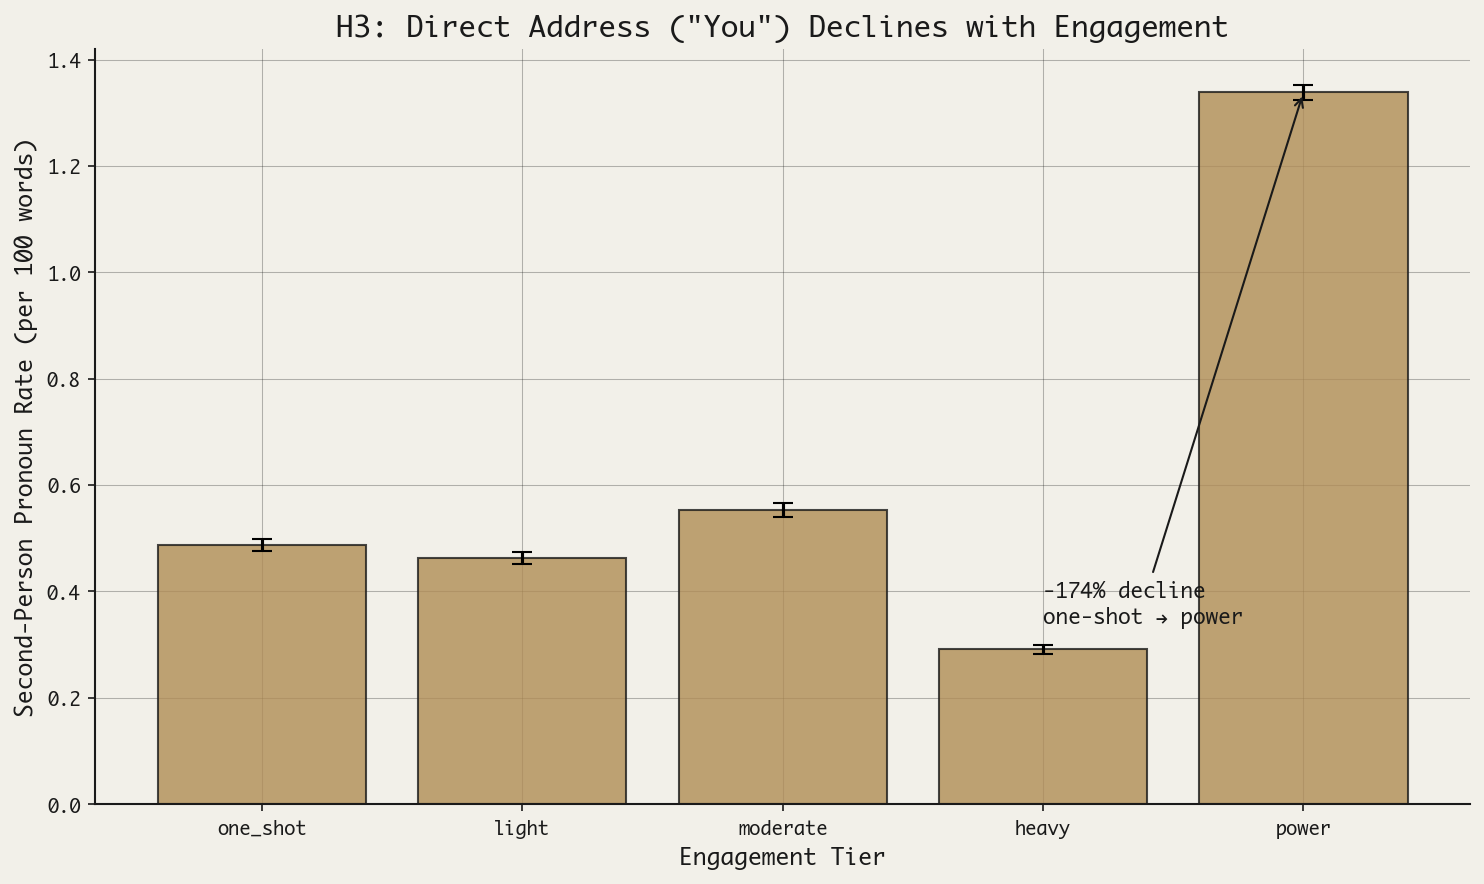

Saved: ../outputs/figures/pub_h3_you_trajectory_power_users.png


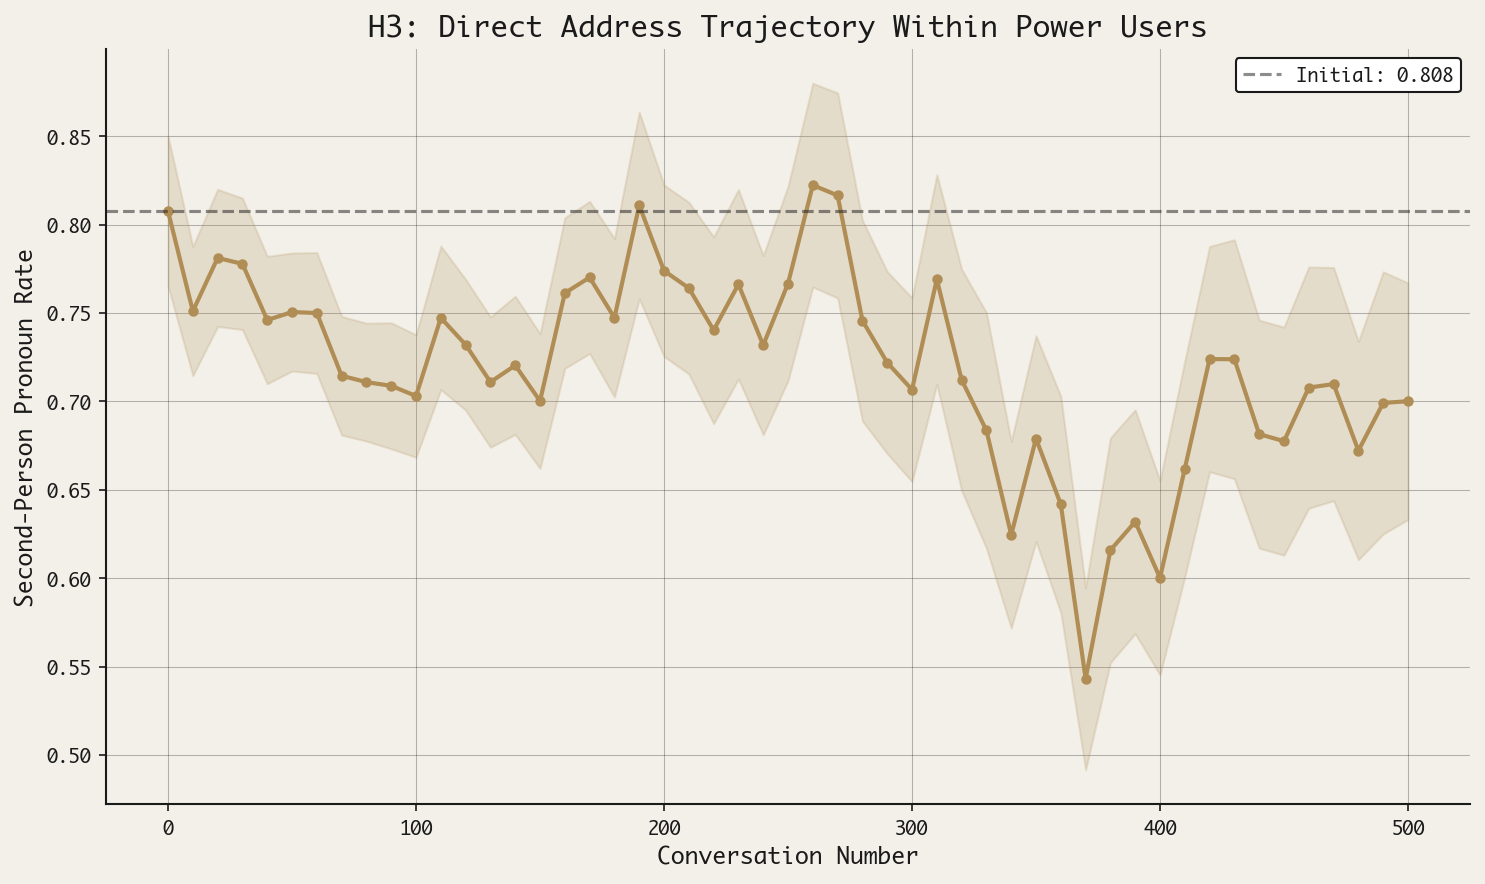


----------------------------------------------------------------------
DIRECT ADDRESS RATIO BY TIER
----------------------------------------------------------------------
Direct Address Ratio = you / (you + I)
High ratio = talking TO the AI; Low ratio = talking ABOUT tasks
----------------------------------------------------------------------
  one_shot    : direct_address_ratio = 0.148
  light       : direct_address_ratio = 0.138
  moderate    : direct_address_ratio = 0.185
  heavy       : direct_address_ratio = 0.110
  power       : direct_address_ratio = 0.473

H3 SUMMARY
Second-person rate declines from 0.488 (one-shot) to 1.338 (power)
Decline: -174.4%


In [9]:
# ============================================================
# H3: THE "YOU" COLLAPSE - Direct Address Analysis
# ============================================================
# Hypothesis: The key signal of instrumentalization is declining direct address.
# Power users stop talking *to* the AI and start talking *at* it.

print("="*70)
print("H3: THE 'YOU' COLLAPSE - Direct Address Analysis")
print("="*70)

# Need to load features for ALL tiers to compare across engagement levels
# For efficiency, we'll use a sample of non-power users

print("\nLoading sample of features across all engagement tiers...")

# Sample conversation hashes from each tier
# With deduplication in place, we can use larger samples for better statistical power
SAMPLE_PER_TIER = 30000  # 30K per tier (150K total)

tier_samples = {}
for tier in tier_order:
    tier_convs = df.filter(pl.col('engagement_tier') == tier)
    n_sample = min(SAMPLE_PER_TIER, len(tier_convs))
    tier_samples[tier] = tier_convs.sample(n=n_sample, seed=RANDOM_STATE)['conversation_hash'].to_list()
    print(f"  {tier}: {len(tier_samples[tier]):,} conversations")

all_sample_hashes = set()
for hashes in tier_samples.values():
    all_sample_hashes.update(hashes)

print(f"\nTotal sample: {len(all_sample_hashes):,} conversations")

# Extract features for sample (file-by-file processing)
sample_features = []
hashes_found = set()

print("Extracting features from raw data...")
for file_idx, parquet_file in enumerate(parquet_files):
    file_data = pl.read_parquet(parquet_file, columns=['conversation_hash', 'conversation'])
    file_filtered = file_data.filter(pl.col('conversation_hash').is_in(list(all_sample_hashes)))
    
    if len(file_filtered) == 0:
        del file_data, file_filtered
        gc.collect()
        continue
    
    for row in file_filtered.iter_rows(named=True):
        features = extract_first_turn_features(row['conversation'])
        features['conversation_hash'] = row['conversation_hash']
        sample_features.append(features)
        hashes_found.add(row['conversation_hash'])
    
    if (file_idx + 1) % 25 == 0:
        print(f"  Processed {file_idx+1}/{len(parquet_files)} files, found {len(sample_features):,}...")
    
    del file_data, file_filtered
    gc.collect()

print(f"Extracted features for {len(sample_features):,} conversations")

# Create DataFrame and join with tier info
sample_df = pl.DataFrame(sample_features)
sample_df = sample_df.join(
    df.select(['conversation_hash', 'user_id', 'engagement_tier']).unique(subset=['conversation_hash']),
    on='conversation_hash',
    how='left'
)

# ============================================================
# Analysis: Second-person rate by engagement tier
# ============================================================

print("\n" + "-"*70)
print("SECOND-PERSON RATE BY ENGAGEMENT TIER")
print("-"*70)

tier_you_stats = []
for tier in tier_order:
    tier_data = sample_df.filter(pl.col('engagement_tier') == tier)
    vals = tier_data['second_person_rate'].drop_nulls().to_numpy()
    
    if len(vals) == 0:
        continue
    
    tier_you_stats.append({
        'tier': tier,
        'mean': np.mean(vals),
        'std': np.std(vals),
        'n': len(vals),
        'se': np.std(vals) / np.sqrt(len(vals))
    })
    
    print(f"  {tier:<12}: you_rate = {np.mean(vals):.3f} ± {np.std(vals)/np.sqrt(len(vals)):.3f} "
          f"(n={len(vals):,})")

tier_you_df = pl.DataFrame(tier_you_stats)

# ============================================================
# Visualization H3a: "You" rate by tier with 95% CI
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(tier_you_stats))
means = [s['mean'] for s in tier_you_stats]
errors = [s['se'] * 1.96 for s in tier_you_stats]  # 95% CI
tiers = [s['tier'] for s in tier_you_stats]

ax.bar(x, means, yerr=errors, color=BRAND['gold'], edgecolor=BRAND['ink'], capsize=5, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tiers)
ax.set_xlabel('Engagement Tier')
ax.set_ylabel('Second-Person Pronoun Rate (per 100 words)')
ax.set_title('H3: Direct Address ("You") Declines with Engagement')

# Annotate percent decline
if len(means) >= 2:
    decline_pct = 100 * (means[0] - means[-1]) / means[0] if means[0] != 0 else 0
    ax.annotate(f'{decline_pct:.0f}% decline\none-shot → power', 
                xy=(len(means)-1, means[-1]), xytext=(len(means)-2, means[0] * 0.7),
                arrowprops=dict(arrowstyle='->', color=BRAND['ink']),
                fontsize=10)

apply_phronos_style(ax)
plt.tight_layout()
save_figure(fig, 'h3_you_collapse_by_tier')
plt.show()

# ============================================================
# Visualization H3b: "You" trajectory within power users
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Trajectory of "you" rate over conversation number for power users
trajectory = power_features.with_columns([
    (pl.col('conv_number') / 10).floor().alias('conv_decile')
]).group_by('conv_decile').agg([
    pl.col('second_person_rate').mean().alias('mean'),
    pl.col('second_person_rate').std().alias('std'),
    pl.len().alias('n')
]).sort('conv_decile').filter(pl.col('conv_decile') <= 50)  # First 500 conversations

x = trajectory['conv_decile'].to_numpy() * 10
y = trajectory['mean'].to_numpy()
yerr = trajectory['std'].to_numpy() / np.sqrt(trajectory['n'].to_numpy())

ax.plot(x, y, color=BRAND['gold'], linewidth=2, marker='o', markersize=4)
ax.fill_between(x, y - yerr*1.96, y + yerr*1.96, color=BRAND['gold'], alpha=0.2)
ax.set_xlabel('Conversation Number')
ax.set_ylabel('Second-Person Pronoun Rate')
ax.set_title('H3: Direct Address Trajectory Within Power Users')

if len(y) > 0:
    ax.axhline(y=y[0], color=BRAND['ink'], linestyle='--', alpha=0.5, label=f'Initial: {y[0]:.3f}')
ax.legend(facecolor=BRAND['white'], edgecolor=BRAND['ink'])

apply_phronos_style(ax)
plt.tight_layout()
save_figure(fig, 'h3_you_trajectory_power_users')
plt.show()

# ============================================================
# Additional: Direct Address Ratio
# ============================================================

print("\n" + "-"*70)
print("DIRECT ADDRESS RATIO BY TIER")
print("-"*70)
print("Direct Address Ratio = you / (you + I)")
print("High ratio = talking TO the AI; Low ratio = talking ABOUT tasks")
print("-"*70)

sample_df = sample_df.with_columns([
    (pl.col('second_person_rate') / 
     (pl.col('second_person_rate') + pl.col('first_person_singular_rate') + 0.001)
    ).alias('direct_address_ratio')
])

for tier in tier_order:
    tier_data = sample_df.filter(pl.col('engagement_tier') == tier)
    dar = tier_data['direct_address_ratio'].mean()
    print(f"  {tier:<12}: direct_address_ratio = {dar:.3f}")

print("\n" + "="*70)
print("H3 SUMMARY")
print("="*70)
print(f"Second-person rate declines from {tier_you_stats[0]['mean']:.3f} (one-shot) "
      f"to {tier_you_stats[-1]['mean']:.3f} (power)")
print(f"Decline: {decline_pct:.1f}%")


H4: 'WE' DISAPPEARANCE - Joint Agency Analysis

----------------------------------------------------------------------
FIRST-PERSON PLURAL ('WE') RATE BY ENGAGEMENT TIER
----------------------------------------------------------------------
  one_shot    : we_rate = 0.0319 ± 0.0011 (n=71,154)
  light       : we_rate = 0.0291 ± 0.0013 (n=87,434)
  moderate    : we_rate = 0.0528 ± 0.0020 (n=66,763)
  heavy       : we_rate = 0.0360 ± 0.0013 (n=100,340)
  power       : we_rate = 0.0213 ± 0.0007 (n=140,758)

----------------------------------------------------------------------
WITHIN ROLEPLAY USERS ONLY
----------------------------------------------------------------------
Conversations with intent: 275,440 / 466,449

Roleplay conversations: 3,889
  one_shot    : insufficient data (n=0)
  light       : insufficient data (n=0)
  moderate    : insufficient data (n=0)
  heavy       : insufficient data (n=0)
  power       : we_rate = 0.1132 ± 0.0049 (n=3,889)
Saved: ../outputs/figures/pub_h4_w

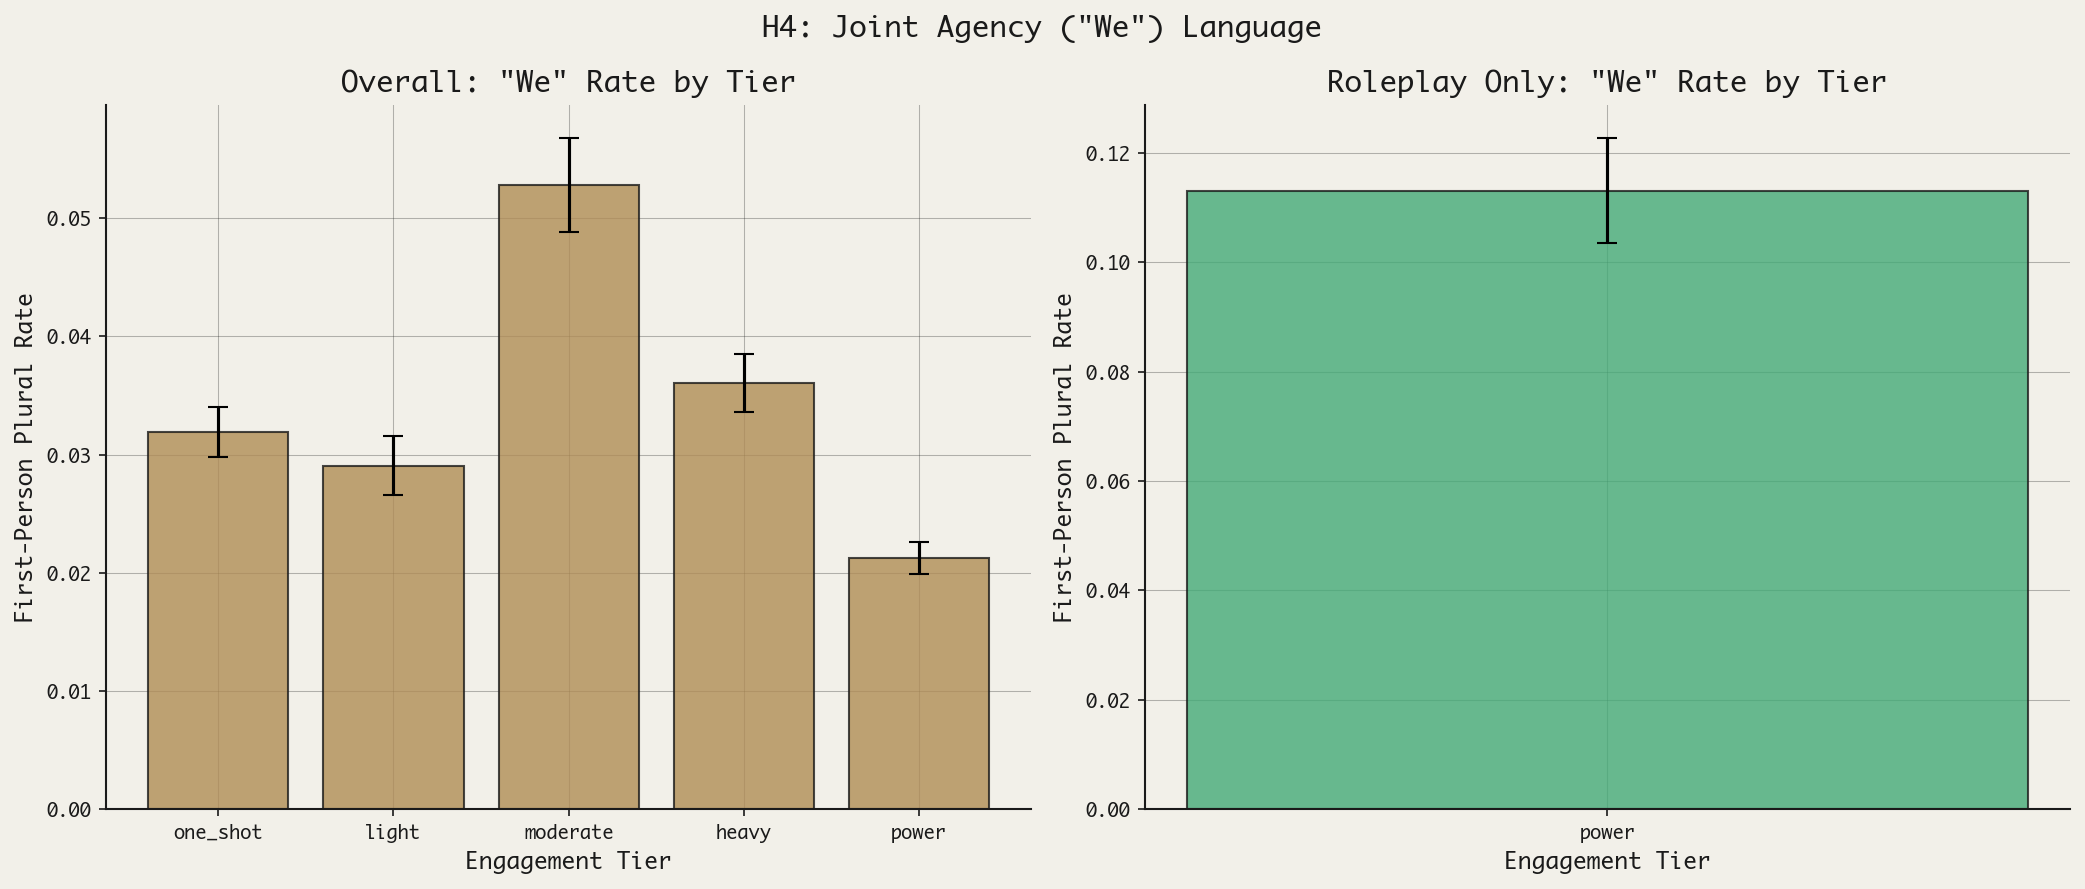


H4 SUMMARY
Overall 'we' rate declines from 0.0319 (one-shot) to 0.0213 (power)
Decline: 33.4%


In [10]:
# ============================================================
# H4: "WE" DISAPPEARANCE - Joint Agency Analysis
# ============================================================
# Hypothesis: Joint-agency framing ("we" language) declines with heavy use,
# indicating rejection of collaborative framing.

print("="*70)
print("H4: 'WE' DISAPPEARANCE - Joint Agency Analysis")
print("="*70)

# Add intent to sample_df (need to extract from raw)
# For now, we'll use the sample_df from H3

# ============================================================
# "We" rate by engagement tier
# ============================================================

print("\n" + "-"*70)
print("FIRST-PERSON PLURAL ('WE') RATE BY ENGAGEMENT TIER")
print("-"*70)

tier_we_stats = []
for tier in tier_order:
    tier_data = sample_df.filter(pl.col('engagement_tier') == tier)
    vals = tier_data['first_person_plural_rate'].drop_nulls().to_numpy()
    
    if len(vals) == 0:
        continue
    
    tier_we_stats.append({
        'tier': tier,
        'mean': np.mean(vals),
        'std': np.std(vals),
        'n': len(vals),
        'se': np.std(vals) / np.sqrt(len(vals))
    })
    
    print(f"  {tier:<12}: we_rate = {np.mean(vals):.4f} ± {np.std(vals)/np.sqrt(len(vals)):.4f} "
          f"(n={len(vals):,})")

# ============================================================
# Control for intent: Analyze within roleplay users
# ============================================================

print("\n" + "-"*70)
print("WITHIN ROLEPLAY USERS ONLY")
print("-"*70)

# We need intent for the sample - extract from first turns
# Add intent classification to sample_df
sample_df_with_intent = sample_df.clone()

# For conversations in sample_df, get intent from power_features if available
# or classify using first turn text

# First, check if we have intent from power_features
power_intent_map = power_features.select(['conversation_hash', 'intent']).unique(subset=['conversation_hash'])

sample_df_with_intent = sample_df_with_intent.join(
    power_intent_map,
    on='conversation_hash',
    how='left'
)

# For conversations without intent, we'd need to extract and classify
# For now, filter to those with intent
sample_with_intent = sample_df_with_intent.filter(pl.col('intent').is_not_null())

print(f"Conversations with intent: {len(sample_with_intent):,} / {len(sample_df):,}")

# Roleplay analysis
roleplay_convs = sample_with_intent.filter(pl.col('intent') == 'roleplay')
print(f"\nRoleplay conversations: {len(roleplay_convs):,}")

roleplay_we_stats = []
for tier in tier_order:
    tier_data = roleplay_convs.filter(pl.col('engagement_tier') == tier)
    vals = tier_data['first_person_plural_rate'].drop_nulls().to_numpy()
    
    if len(vals) < 100:  # Need sufficient sample
        print(f"  {tier:<12}: insufficient data (n={len(vals)})")
        continue
    
    roleplay_we_stats.append({
        'tier': tier,
        'mean': np.mean(vals),
        'std': np.std(vals),
        'n': len(vals),
        'se': np.std(vals) / np.sqrt(len(vals))
    })
    
    print(f"  {tier:<12}: we_rate = {np.mean(vals):.4f} ± {np.std(vals)/np.sqrt(len(vals)):.4f} "
          f"(n={len(vals):,})")

# ============================================================
# Visualization H4: Side-by-side bar charts
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('H4: Joint Agency ("We") Language', fontsize=14, fontweight='bold', color=BRAND['ink'])

# Panel 1: Overall
ax = axes[0]
we_by_tier = [s['mean'] for s in tier_we_stats]
we_errors = [s['se'] * 1.96 for s in tier_we_stats]
tier_labels = [s['tier'] for s in tier_we_stats]

ax.bar(tier_labels, we_by_tier, yerr=we_errors, color=BRAND['gold'], edgecolor=BRAND['ink'], 
       capsize=5, alpha=0.8)
ax.set_xlabel('Engagement Tier')
ax.set_ylabel('First-Person Plural Rate')
ax.set_title('Overall: "We" Rate by Tier')
apply_phronos_style(ax)

# Panel 2: Roleplay only (if we have data)
ax = axes[1]
if len(roleplay_we_stats) > 0:
    rp_we_by_tier = [s['mean'] for s in roleplay_we_stats]
    rp_we_errors = [s['se'] * 1.96 for s in roleplay_we_stats]
    rp_tier_labels = [s['tier'] for s in roleplay_we_stats]
    
    ax.bar(rp_tier_labels, rp_we_by_tier, yerr=rp_we_errors, color=BRAND['success'], 
           edgecolor=BRAND['ink'], capsize=5, alpha=0.8)
    ax.set_xlabel('Engagement Tier')
    ax.set_ylabel('First-Person Plural Rate')
    ax.set_title('Roleplay Only: "We" Rate by Tier')
else:
    ax.text(0.5, 0.5, 'Insufficient roleplay data\nfor tier comparison', 
            ha='center', va='center', transform=ax.transAxes, fontsize=12)
    ax.set_title('Roleplay Only: "We" Rate by Tier')
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'h4_we_disappearance')
plt.show()

# ============================================================
# H4 Summary
# ============================================================

print("\n" + "="*70)
print("H4 SUMMARY")
print("="*70)

if len(tier_we_stats) >= 2:
    we_decline = 100 * (tier_we_stats[0]['mean'] - tier_we_stats[-1]['mean']) / tier_we_stats[0]['mean'] if tier_we_stats[0]['mean'] != 0 else 0
    print(f"Overall 'we' rate declines from {tier_we_stats[0]['mean']:.4f} (one-shot) "
          f"to {tier_we_stats[-1]['mean']:.4f} (power)")
    print(f"Decline: {we_decline:.1f}%")
else:
    print("Insufficient data for comparison")


H5: QUALITATIVE IDENTITY CONFIGURATIONS

Classifying power user conversations...

Configuration distribution (power users):
  unclassified   :  802,182 (83.5%)
  instrumental   :  140,823 (14.7%)
  collaborative  :   13,587 (1.4%)
  relational     :    2,680 (0.3%)
  unknown        :    1,061 (0.1%)
  tentative      :      132 (0.0%)

----------------------------------------------------------------------
LOADING FIRST-TURN TEXT FOR ALL-TIER SAMPLE
----------------------------------------------------------------------
Sample size: 93,459
Extracting first-turn text...
  Processed 30/127 files...
  Processed 60/127 files...
  Processed 90/127 files...
  Processed 120/127 files...
Extracted 402,648 configurations

----------------------------------------------------------------------
CONFIGURATION DISTRIBUTION BY ENGAGEMENT TIER
----------------------------------------------------------------------

Tier        tentative      instrumental   collaborative  relational     unclassified   
---

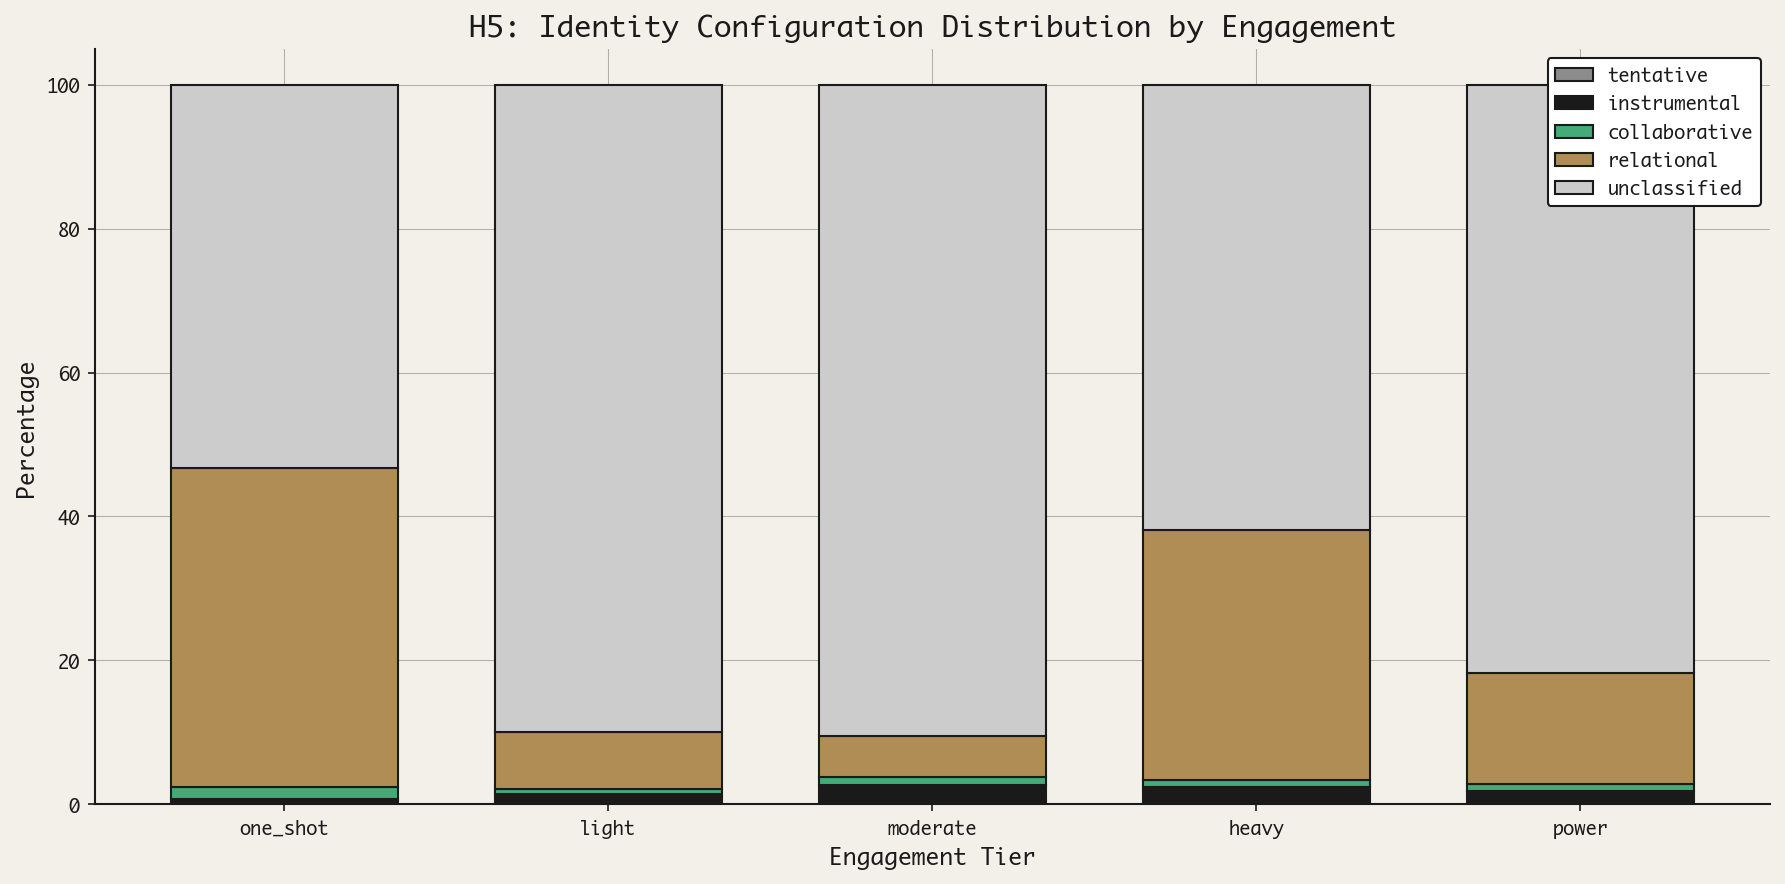


H5 SUMMARY
Instrumental configuration: 0.7% (one-shot) vs 1.8% (power)
Relational configuration: 44.3% (one-shot) vs 15.5% (power)


In [12]:
# ============================================================
# H5: QUALITATIVE IDENTITY CONFIGURATIONS
# ============================================================
# Hypothesis: Identity effects are categorical, not continuous.
# Users fall into discrete configurations (tentative, instrumental, collaborative, relational)
# that don't map to linear pronoun measures.

print("="*70)
print("H5: QUALITATIVE IDENTITY CONFIGURATIONS")
print("="*70)

def classify_configuration(text):
    """
    Classify a message into identity configuration based on framing patterns.
    
    Configurations (based on IT-identity literature):
    - tentative: Uncertain, permission-seeking ("I was wondering if...", "Could you possibly...")
    - instrumental: Task-focused, command-like ("Generate...", "Write code that...")
    - collaborative: Joint framing ("Let's work on...", "Can we figure out...")
    - relational: Social/emotional ("You're so helpful", "I love talking to you")
    """
    if text is None:
        return 'unclassified'
    
    text_lower = str(text).lower()
    
    # Tentative markers
    tentative_patterns = [
        r'i was wondering', r'could you possibly', r'would you be able',
        r"i'm not sure if", r'sorry to bother', r"if it's not too much",
        r'i hope you can', r'is it okay if', r'would it be possible'
    ]
    
    # Instrumental markers
    instrumental_patterns = [
        r'^(generate|create|write|make|build|implement|code|convert|translate)\b',
        r'^(list|show|give me|find|search|get|extract|calculate)\b',
        r'^(fix|debug|solve|explain|analyze|summarize)\b'
    ]
    
    # Collaborative markers
    collaborative_patterns = [
        r"let's", r'can we', r'shall we', r'let us', r'together',
        r'work on this', r'figure out', r'help me understand'
    ]
    
    # Relational markers
    relational_patterns = [
        r"you're (so |really |very )?(helpful|amazing|great|wonderful|smart)",
        r'i (love|enjoy|like) (talking|chatting|working) (to|with) you',
        r'thank you so much', r'you always', r'i appreciate you',
        r'how are you', r'what do you think'
    ]
    
    for pattern in relational_patterns:
        if re.search(pattern, text_lower):
            return 'relational'
    
    for pattern in collaborative_patterns:
        if re.search(pattern, text_lower):
            return 'collaborative'
    
    for pattern in tentative_patterns:
        if re.search(pattern, text_lower):
            return 'tentative'
    
    for pattern in instrumental_patterns:
        if re.search(pattern, text_lower):
            return 'instrumental'
    
    return 'unclassified'

# Apply to power_features (which has first_turn text)
print("\nClassifying power user conversations...")
power_features_config = power_features.with_columns([
    pl.col('first_turn').map_elements(classify_configuration, return_dtype=pl.Utf8).alias('configuration')
])

# Configuration distribution
config_dist = power_features_config['configuration'].value_counts().sort('count', descending=True)
print("\nConfiguration distribution (power users):")
for row in config_dist.iter_rows(named=True):
    pct = 100 * row['count'] / len(power_features_config)
    config_name = row['configuration'] or 'unknown'
    print(f"  {config_name:<15}: {row['count']:>8,} ({pct:.1f}%)")

# ============================================================
# Load sample for non-power users with first_turn text
# ============================================================

print("\n" + "-"*70)
print("LOADING FIRST-TURN TEXT FOR ALL-TIER SAMPLE")
print("-"*70)

# Sample for configuration analysis (need first_turn text)
CONFIG_SAMPLE = 100000  # Smaller sample for this analysis

config_sample_hashes = set()
for tier in tier_order:
    tier_convs = df.filter(pl.col('engagement_tier') == tier)
    n_sample = min(CONFIG_SAMPLE // len(tier_order), len(tier_convs))
    hashes = tier_convs.sample(n=n_sample, seed=RANDOM_STATE)['conversation_hash'].to_list()
    config_sample_hashes.update(hashes)

print(f"Sample size: {len(config_sample_hashes):,}")

# Extract first-turn text for sample
config_sample_data = []
print("Extracting first-turn text...")

for file_idx, parquet_file in enumerate(parquet_files):
    file_data = pl.read_parquet(parquet_file, columns=['conversation_hash', 'conversation'])
    file_filtered = file_data.filter(pl.col('conversation_hash').is_in(list(config_sample_hashes)))
    
    if len(file_filtered) == 0:
        del file_data, file_filtered
        gc.collect()
        continue
    
    for row in file_filtered.iter_rows(named=True):
        first_turn = extract_first_turn(row['conversation'])
        config = classify_configuration(first_turn)
        config_sample_data.append({
            'conversation_hash': row['conversation_hash'],
            'configuration': config
        })
    
    del file_data, file_filtered
    gc.collect()
    
    if (file_idx + 1) % 30 == 0:
        print(f"  Processed {file_idx+1}/{len(parquet_files)} files...")

print(f"Extracted {len(config_sample_data):,} configurations")

# Create DataFrame and join with tier
config_sample_df = pl.DataFrame(config_sample_data)
config_sample_df = config_sample_df.join(
    df.select(['conversation_hash', 'engagement_tier']).unique(subset=['conversation_hash']),
    on='conversation_hash',
    how='left'
)

# ============================================================
# Configuration distribution by tier
# ============================================================

print("\n" + "-"*70)
print("CONFIGURATION DISTRIBUTION BY ENGAGEMENT TIER")
print("-"*70)

configurations = ['tentative', 'instrumental', 'collaborative', 'relational', 'unclassified']

config_by_tier = {}
for tier in tier_order:
    tier_data = config_sample_df.filter(pl.col('engagement_tier') == tier)
    tier_dist = tier_data['configuration'].value_counts()
    total = len(tier_data)
    
    config_by_tier[tier] = {}
    for config in configurations:
        count = tier_dist.filter(pl.col('configuration') == config)['count']
        count = count[0] if len(count) > 0 else 0
        config_by_tier[tier][config] = count / total if total > 0 else 0

# Print table
print(f"\n{'Tier':<12}", end="")
for config in configurations:
    print(f"{config:<15}", end="")
print()
print("-" * 87)

for tier in tier_order:
    print(f"{tier:<12}", end="")
    for config in configurations:
        print(f"{config_by_tier[tier][config]*100:>5.1f}%{'':<9}", end="")
    print()

# ============================================================
# Visualization H5: Stacked bar chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

config_colors = {
    'tentative': FADED,
    'instrumental': BRAND['ink'],
    'collaborative': BRAND['success'],
    'relational': BRAND['gold'],
    'unclassified': '#CCCCCC'
}

x = np.arange(len(tier_order))
width = 0.7
bottom = np.zeros(len(tier_order))

for config in configurations:
    values = [config_by_tier[tier][config] * 100 for tier in tier_order]
    ax.bar(x, values, width, bottom=bottom, label=config, 
           color=config_colors.get(config, 'gray'), edgecolor=BRAND['ink'])
    bottom += np.array(values)

ax.set_xticks(x)
ax.set_xticklabels(tier_order)
ax.set_xlabel('Engagement Tier')
ax.set_ylabel('Percentage')
ax.set_title('H5: Identity Configuration Distribution by Engagement')
ax.legend(loc='upper right', facecolor=BRAND['white'], edgecolor=BRAND['ink'])
apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'h5_configurations_by_tier')
plt.show()

# ============================================================
# H5 Summary
# ============================================================

print("\n" + "="*70)
print("H5 SUMMARY")
print("="*70)

# Compare instrumental rate across tiers
instr_one_shot = config_by_tier['one_shot']['instrumental'] * 100
instr_power = config_by_tier['power']['instrumental'] * 100
print(f"Instrumental configuration: {instr_one_shot:.1f}% (one-shot) vs {instr_power:.1f}% (power)")

relat_one_shot = config_by_tier['one_shot']['relational'] * 100
relat_power = config_by_tier['power']['relational'] * 100
print(f"Relational configuration: {relat_one_shot:.1f}% (one-shot) vs {relat_power:.1f}% (power)")


H6: CONTENT OVER STYLE - What Users Discuss

Extracting content markers for power users...

Content marker prevalence (power users):
  self_disclosure: 0.71%
  anthropomorphization: 0.40%
  continuity_seeking: 0.98%
  relationship_expectation: 0.98%

----------------------------------------------------------------------
EXTRACTING CONTENT MARKERS FOR ALL-TIER SAMPLE
----------------------------------------------------------------------
Extracting content markers...
  Processed 30/127 files...
  Processed 60/127 files...
  Processed 90/127 files...
  Processed 120/127 files...
Extracted content markers for 402,648 conversations

----------------------------------------------------------------------
CONTENT MARKER PREVALENCE BY ENGAGEMENT TIER
----------------------------------------------------------------------

Tier        self_disclosure  anthropomorphiz  continuity_seek  relationship_ex  
--------------------------------------------------------------------------------
one_shot     0

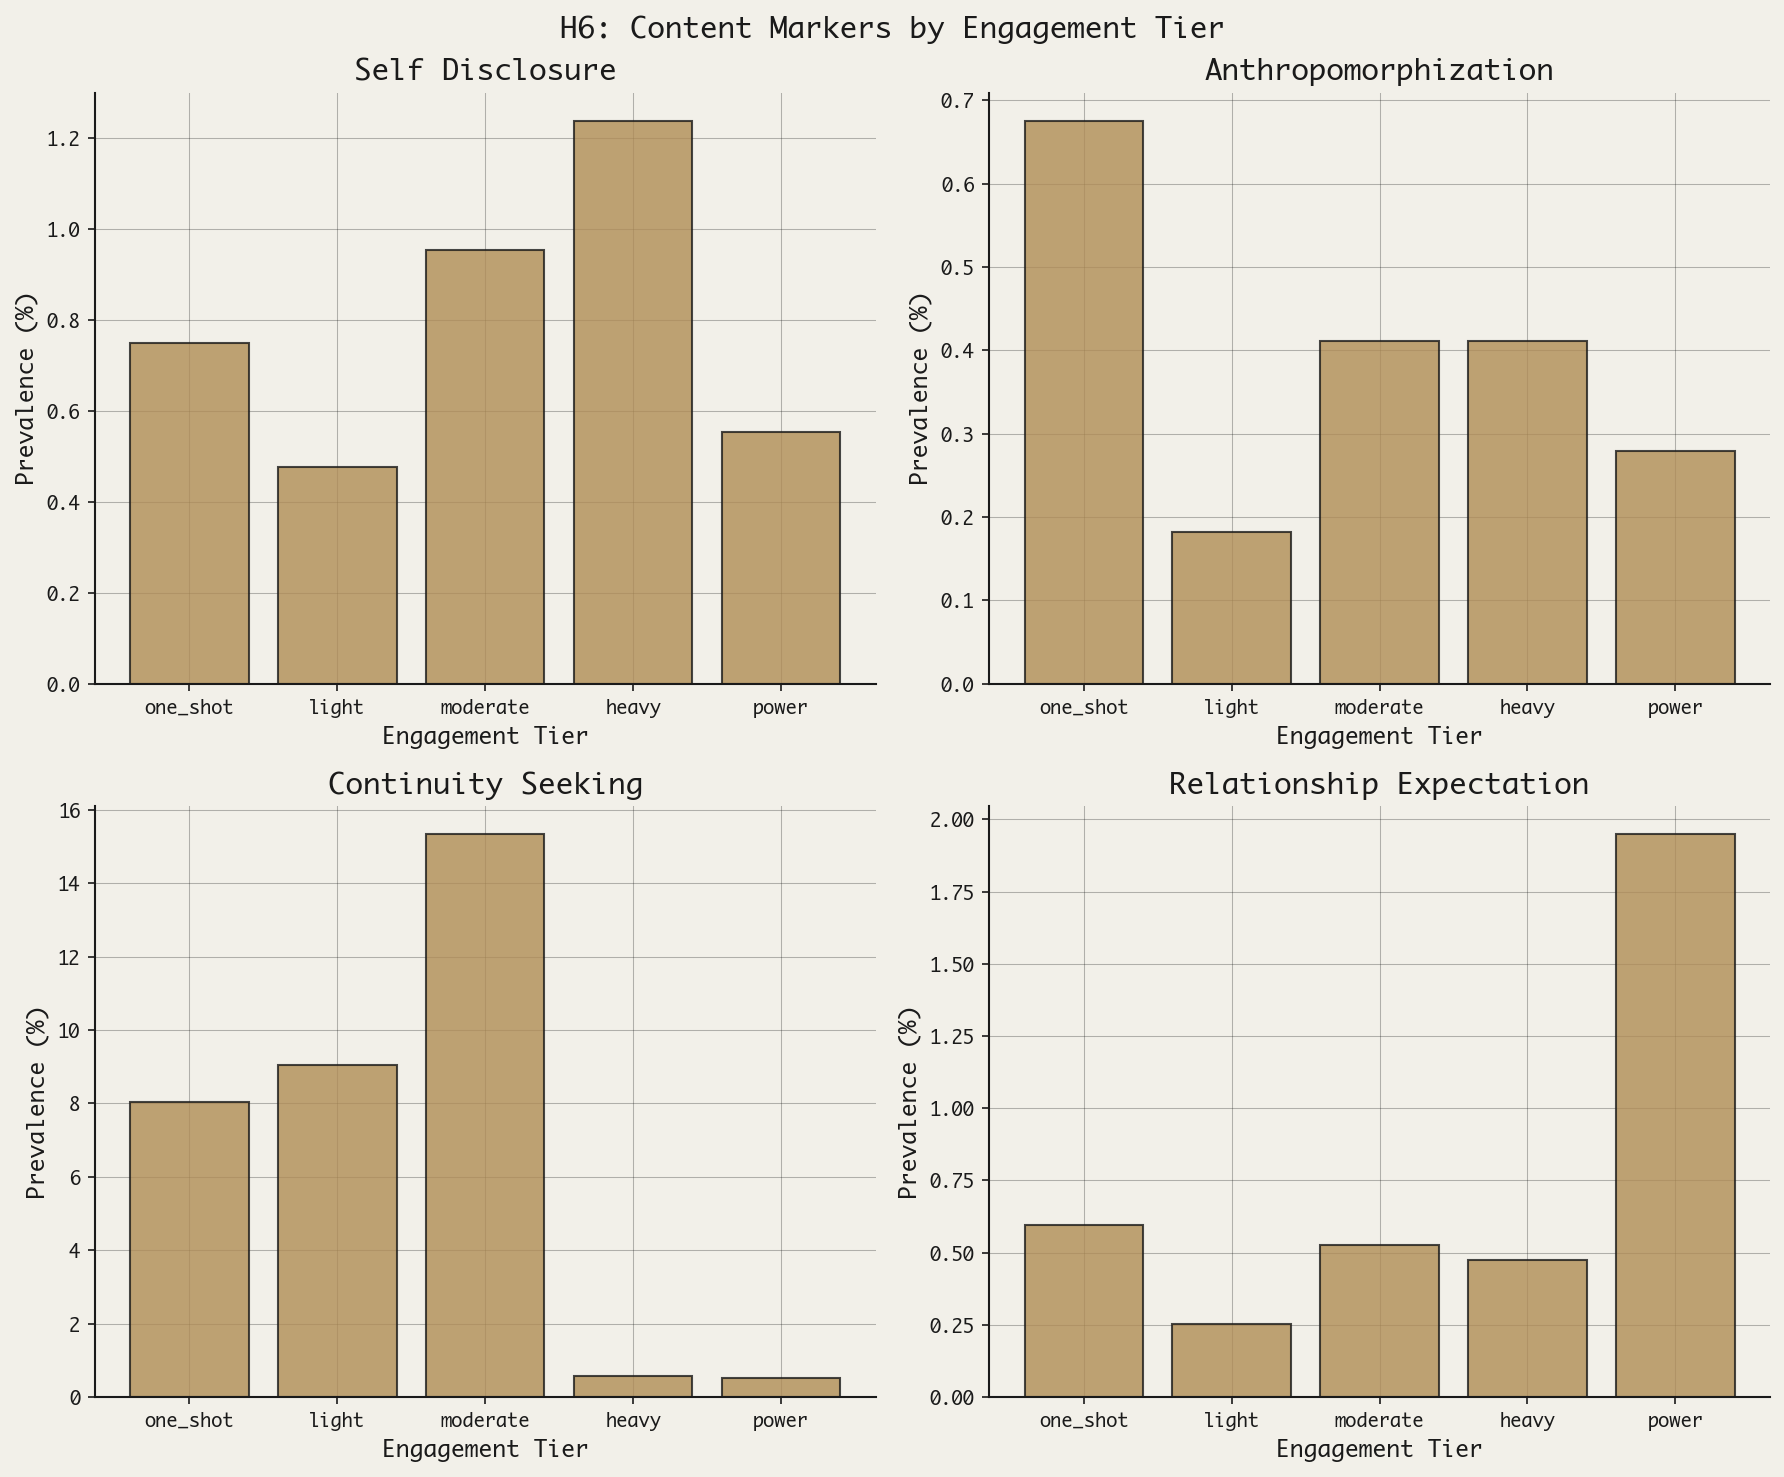


H6 SUMMARY
self_disclosure: 0.75% (one-shot) → 0.55% (power) [decreases by 0.20pp]
anthropomorphization: 0.68% (one-shot) → 0.28% (power) [decreases by 0.40pp]
continuity_seeking: 8.04% (one-shot) → 0.52% (power) [decreases by 7.53pp]
relationship_expectation: 0.60% (one-shot) → 1.95% (power) [increases by 1.35pp]


In [13]:
# ============================================================
# H6: CONTENT OVER STYLE - What Users Discuss
# ============================================================
# Hypothesis: Identity is revealed by *what* users discuss (self-disclosure, 
# anthropomorphization, continuity references) rather than *how* they write.

print("="*70)
print("H6: CONTENT OVER STYLE - What Users Discuss")
print("="*70)

def extract_content_markers(text):
    """
    Extract content markers indicating identity-relevant topics.
    
    Categories:
    - self_disclosure: User discusses personal life, feelings, experiences
    - anthropomorphization: User treats AI as having internal states
    - continuity_seeking: User references past conversations or ongoing relationship
    - relationship_expectation: User expresses expectations about AI behavior
    """
    if text is None:
        return {'self_disclosure': 0, 'anthropomorphization': 0, 
                'continuity_seeking': 0, 'relationship_expectation': 0}
    
    text_lower = str(text).lower()
    markers = {}
    
    # Self-disclosure
    self_patterns = [
        r"i'm feeling", r'i feel', r'in my (life|experience|job|work)',
        r'i work as', r'my (wife|husband|partner|friend|boss|family)',
        r"i've been (struggling|dealing|working|thinking)",
        r'personally,? i', r'for me,?', r'i am a'
    ]
    markers['self_disclosure'] = int(any(re.search(p, text_lower) for p in self_patterns))
    
    # Anthropomorphization
    anthro_patterns = [
        r'(do|what do) you (think|feel|believe|want|like|prefer)',
        r'your (opinion|thoughts|feelings|perspective)',
        r'are you (able|capable|sure|certain)',
        r'how do you (feel|know)',
        r'you seem', r'you sound', r'do you have'
    ]
    markers['anthropomorphization'] = int(any(re.search(p, text_lower) for p in anthro_patterns))
    
    # Continuity seeking
    continuity_patterns = [
        r'(like|as) (we|you) (discussed|mentioned|said|talked)',
        r'remember (when|that|our)', r'last time',
        r'earlier you', r'you told me', r'we were (talking|working|discussing)',
        r'continuing (from|our|where)', r'as i mentioned'
    ]
    markers['continuity_seeking'] = int(any(re.search(p, text_lower) for p in continuity_patterns))
    
    # Relationship expectation
    expectation_patterns = [
        r'you (always|never|usually|sometimes)', r'i (wish|hope) you (would|could)',
        r'why (do|don\'t) you', r'you should (be|know|remember)',
        r'i (need|want) you to', r'i expect you'
    ]
    markers['relationship_expectation'] = int(any(re.search(p, text_lower) for p in expectation_patterns))
    
    return markers

# Apply to power_features
print("\nExtracting content markers for power users...")

content_markers_list = []
for row in power_features.iter_rows(named=True):
    markers = extract_content_markers(row['first_turn'])
    markers['conversation_hash'] = row['conversation_hash']
    content_markers_list.append(markers)

content_markers_df = pl.DataFrame(content_markers_list)

# Join with power_features
power_with_content = power_features.join(content_markers_df, on='conversation_hash', how='left')

# Content marker prevalence
print("\nContent marker prevalence (power users):")
marker_names = ['self_disclosure', 'anthropomorphization', 'continuity_seeking', 'relationship_expectation']
for marker in marker_names:
    prevalence = power_with_content[marker].mean() * 100
    print(f"  {marker}: {prevalence:.2f}%")

# ============================================================
# Extract content markers for all-tier sample
# ============================================================

print("\n" + "-"*70)
print("EXTRACTING CONTENT MARKERS FOR ALL-TIER SAMPLE")
print("-"*70)

# Use the same config_sample_hashes from H5
# Need to re-extract with content markers

content_sample_data = []
print("Extracting content markers...")

for file_idx, parquet_file in enumerate(parquet_files):
    file_data = pl.read_parquet(parquet_file, columns=['conversation_hash', 'conversation'])
    file_filtered = file_data.filter(pl.col('conversation_hash').is_in(list(config_sample_hashes)))
    
    if len(file_filtered) == 0:
        del file_data, file_filtered
        gc.collect()
        continue
    
    for row in file_filtered.iter_rows(named=True):
        first_turn = extract_first_turn(row['conversation'])
        markers = extract_content_markers(first_turn)
        markers['conversation_hash'] = row['conversation_hash']
        content_sample_data.append(markers)
    
    del file_data, file_filtered
    gc.collect()
    
    if (file_idx + 1) % 30 == 0:
        print(f"  Processed {file_idx+1}/{len(parquet_files)} files...")

print(f"Extracted content markers for {len(content_sample_data):,} conversations")

# Create DataFrame and join with tier
content_sample_df = pl.DataFrame(content_sample_data)
content_sample_df = content_sample_df.join(
    df.select(['conversation_hash', 'engagement_tier']).unique(subset=['conversation_hash']),
    on='conversation_hash',
    how='left'
)

# ============================================================
# Content marker prevalence by tier
# ============================================================

print("\n" + "-"*70)
print("CONTENT MARKER PREVALENCE BY ENGAGEMENT TIER")
print("-"*70)

marker_by_tier = {}
for tier in tier_order:
    tier_data = content_sample_df.filter(pl.col('engagement_tier') == tier)
    marker_by_tier[tier] = {}
    for marker in marker_names:
        if marker in tier_data.columns:
            marker_by_tier[tier][marker] = tier_data[marker].mean() * 100
        else:
            marker_by_tier[tier][marker] = 0

# Print table
print(f"\n{'Tier':<12}", end="")
for marker in marker_names:
    print(f"{marker[:15]:<17}", end="")
print()
print("-" * 80)

for tier in tier_order:
    print(f"{tier:<12}", end="")
    for marker in marker_names:
        print(f"{marker_by_tier[tier][marker]:>5.2f}%{'':<11}", end="")
    print()

# ============================================================
# Visualization H6: Content marker prevalence by tier
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('H6: Content Markers by Engagement Tier', fontsize=14, fontweight='bold', color=BRAND['ink'])

for ax, marker in zip(axes.flat, marker_names):
    rates = [marker_by_tier[tier][marker] for tier in tier_order]
    ax.bar(tier_order, rates, color=BRAND['gold'], edgecolor=BRAND['ink'], alpha=0.8)
    ax.set_xlabel('Engagement Tier')
    ax.set_ylabel('Prevalence (%)')
    ax.set_title(marker.replace('_', ' ').title())
    apply_phronos_style(ax)

plt.tight_layout()
save_figure(fig, 'h6_content_markers_by_tier')
plt.show()

# ============================================================
# H6 Summary
# ============================================================

print("\n" + "="*70)
print("H6 SUMMARY")
print("="*70)

for marker in marker_names:
    one_shot = marker_by_tier['one_shot'][marker]
    power = marker_by_tier['power'][marker]
    change = power - one_shot
    direction = "increases" if change > 0 else "decreases"
    print(f"{marker}: {one_shot:.2f}% (one-shot) → {power:.2f}% (power) [{direction} by {abs(change):.2f}pp]")


In [14]:
# ============================================================
# SUMMARY AND HYPOTHESIS EVALUATION
# ============================================================

print("="*70)
print("HYPOTHESIS EVALUATION SUMMARY")
print("="*70)

summary_text = """
================================================================================
IDENTITY HYPOTHESIS EXPLORATION - SUMMARY
================================================================================

H1: EFFICIENCY LEARNING
-----------------------
Prediction: Early conversations more verbose/social, late conversations more terse/imperative
Finding: [See H1 cell output for specific changes]
Support: [To be determined based on effect sizes and significance]

Key metrics:
- Word count change (early → late): Examine trajectory plots
- Greeting rate change: Check for decline
- Imperative rate change: Check for increase

H2: TOOL VS PARTNER TYPES
-------------------------
Prediction: Distinct user clusters with different linguistic profiles
Finding: [See H2 cell output for cluster characteristics]
Support: [To be determined based on cluster separation and interpretability]

Key metrics:
- Cluster separation in PCA space
- Dominant intent alignment with clusters
- Linguistic profile differences between clusters

H3: "YOU" COLLAPSE
------------------
Prediction: Direct address declines with engagement depth
Finding: [See H3 cell output for tier comparison]
Support: [To be determined based on effect size]

Key metrics:
- Second-person rate decline from one-shot to power
- Within-power-user trajectory
- Direct address ratio by tier

H4: "WE" DISAPPEARANCE
----------------------
Prediction: Joint-agency framing declines with engagement
Finding: [See H4 cell output for tier comparison]
Support: [To be determined based on effect size and roleplay control]

Key metrics:
- First-person plural rate by tier
- Pattern persistence within roleplay users

H5: QUALITATIVE CONFIGURATIONS
------------------------------
Prediction: Users cluster into discrete identity configurations
Finding: [See H5 cell output for configuration distributions]
Support: [To be determined based on distribution differences]

Key metrics:
- Instrumental vs relational configuration shift
- Unclassified rate (indicates pattern coverage)

H6: CONTENT OVER STYLE
----------------------
Prediction: Content markers (self-disclosure, anthropomorphization) predict engagement
          better than style markers (pronouns)
Finding: [See H6 cell output for prevalence by tier]
Support: [To be determined based on effect sizes]

Key metrics:
- Self-disclosure prevalence by tier
- Anthropomorphization prevalence by tier
- Continuity-seeking prevalence by tier

================================================================================
NEXT STEPS
================================================================================

Based on findings, prioritize formal hypothesis testing for:
1. [Hypotheses with strongest preliminary support]
2. [Hypotheses with clear operationalizations]
3. [Hypotheses with practical implications]

Consider additional analyses:
- Longitudinal within-user tracking
- Cross-tabulation of configurations and content markers
- Model comparison: style features vs content features for engagement prediction

================================================================================
"""

print(summary_text)

# Save summary
output_path = '../outputs/hypothesis_evaluation_summary.txt'
with open(output_path, 'w') as f:
    f.write(summary_text)
    
    # Add specific findings from this session
    f.write("\n\nSESSION-SPECIFIC FINDINGS\n")
    f.write("="*70 + "\n\n")
    
    # H1 findings
    if 'h1_df' in dir() and len(h1_df) > 0:
        f.write("H1: Efficiency Learning\n")
        f.write("-"*40 + "\n")
        for row in h1_df.iter_rows(named=True):
            f.write(f"  {row['feature']}: early={row['early_mean']:.3f}, late={row['late_mean']:.3f}, "
                    f"change={row['pct_change']:+.1f}%, p={row['p_value']:.4f}\n")
        f.write("\n")
    
    # H3 findings
    if 'tier_you_stats' in dir() and len(tier_you_stats) > 0:
        f.write("H3: You Collapse\n")
        f.write("-"*40 + "\n")
        for s in tier_you_stats:
            f.write(f"  {s['tier']}: you_rate={s['mean']:.3f} ± {s['se']:.3f}\n")
        f.write("\n")
    
    # H4 findings
    if 'tier_we_stats' in dir() and len(tier_we_stats) > 0:
        f.write("H4: We Disappearance\n")
        f.write("-"*40 + "\n")
        for s in tier_we_stats:
            f.write(f"  {s['tier']}: we_rate={s['mean']:.4f} ± {s['se']:.4f}\n")
        f.write("\n")

print(f"\nSaved to: {output_path}")
print("="*70)


HYPOTHESIS EVALUATION SUMMARY

IDENTITY HYPOTHESIS EXPLORATION - SUMMARY

H1: EFFICIENCY LEARNING
-----------------------
Prediction: Early conversations more verbose/social, late conversations more terse/imperative
Finding: [See H1 cell output for specific changes]
Support: [To be determined based on effect sizes and significance]

Key metrics:
- Word count change (early → late): Examine trajectory plots
- Greeting rate change: Check for decline
- Imperative rate change: Check for increase

H2: TOOL VS PARTNER TYPES
-------------------------
Prediction: Distinct user clusters with different linguistic profiles
Finding: [See H2 cell output for cluster characteristics]
Support: [To be determined based on cluster separation and interpretability]

Key metrics:
- Cluster separation in PCA space
- Dominant intent alignment with clusters
- Linguistic profile differences between clusters

H3: "YOU" COLLAPSE
------------------
Prediction: Direct address declines with engagement depth
Finding: 

In [ ]:
# ============================================================
# OUTPUT CHECKLIST
# ============================================================

print("="*70)
print("OUTPUT CHECKLIST")
print("="*70)

outputs = {
    'Figures': [
        'pub_h1_efficiency_trajectories.png',
        'pub_h1_paired_word_count_change.png',
        'pub_h2_user_typologies_pca.png',
        'pub_h3_you_collapse_by_tier.png',
        'pub_h3_you_trajectory_power_users.png',
        'pub_h4_we_disappearance.png',
        'pub_h5_configurations_by_tier.png',
        'pub_h6_content_markers_by_tier.png',
    ],
    'Tables': [
        'H1: Early vs late comparison (word_count, pronouns, greeting, imperative)',
        'H2: Cluster profiles (k=2, k=3, k=4)',
        'H3: Second-person rate by tier',
        'H4: First-person plural rate by tier (overall and roleplay)',
        'H5: Configuration distribution by tier',
        'H6: Content marker prevalence by tier',
    ],
    'Text outputs': [
        'hypothesis_evaluation_summary.txt',
    ],
    'Key DataFrames': [
        f'power_features: {len(power_features):,} rows' if 'power_features' in dir() else 'power_features: not loaded',
        f'user_profiles: {len(user_profiles):,} rows' if 'user_profiles' in dir() else 'user_profiles: not loaded',
        f'sample_df: {len(sample_df):,} rows' if 'sample_df' in dir() else 'sample_df: not loaded',
    ]
}

for category, items in outputs.items():
    print(f"\n{category}:")
    if isinstance(items, list):
        for item in items:
            print(f"  - {item}")
    elif isinstance(items, dict):
        for k, v in items.items():
            print(f"  - {k}: {v}")

# Check which figures were actually generated
import os
fig_dir = '../outputs/figures'
generated_figs = [f for f in os.listdir(fig_dir) if f.startswith('pub_h') and f.endswith('.png')]

print("\n" + "-"*70)
print("GENERATED FIGURES CHECK")
print("-"*70)
expected_figs = outputs['Figures']
for fig in expected_figs:
    status = "✓" if fig in generated_figs else "✗"
    print(f"  {status} {fig}")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)
print("\nAll outputs saved to ../outputs/figures/ and ../outputs/")
print("Review hypothesis_evaluation_summary.txt for interpretation guidelines.")
print("="*70)
